In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel

from chronos import ChronosPipeline
import torch
import torch.nn as nn

def parse_parameters(file_path):
    """
    Читает файл parameters.txt и возвращает словарь с нужными параметрами
    """
    params = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                key = parts[0]
                value = ' '.join(parts[1:])  # на случай, если значение содержит пробелы
                params[key] = value
    # Извлекаем нужные параметры
    result = {}
    for param in ['PName', 'Msw', 'XUVInt', 'H2a', 'Helium']:
        result[param] = params.get(param)
    return result

def process_files_in_folder_with_params(root_folder):
    """
    Рекурсивно проходит по папке, читает параметры и файлы с данными
    Возвращает список словарей, где каждый словарь — это один файл
    """
    dataset = []
    root = Path(root_folder)
    for data_file_path in root.rglob('*[.txt,.dat]'):
        if data_file_path.name == 'parameters.txt':
            continue  # Пропускаем файл параметров

        # Ищем файл parameters.txt в той же папке
        param_file_path = data_file_path.parent / 'parameters.txt'

        if param_file_path.exists():
            params = parse_parameters(param_file_path)
            # print(f"Файл: {data_file_path}")
            # print(f"Параметры: {params}")
        else:
            # print(f"Файл parameters.txt не найден для {data_file_path}")
            params = {}

        # Читаем V и FullAbs из data файла
        try:
            V, FullAbs = np.loadtxt(data_file_path, usecols=(0, 1), unpack=True, skiprows=1)
            entry = {
                'V': V,
                'FullAbs': FullAbs,
                'PName': params.get('PName'),
                'Msw': params.get('Msw'),
                'XUVInt': params.get('XUVInt'),
                'H2a': params.get('H2a'),
                'Helium': params.get('Helium'),
                # 'File': str(data_file_path)  # можно убрать, если не нужно
            }
            dataset.append(entry)
        except Exception as e:
            print(f"Ошибка при загрузке данных из {data_file_path}: {e}")
        # print("-" * 50)

    return dataset

def pad_or_truncate(seq, target_len=101, pad_value=0.0):
    seq = np.array(seq, dtype=np.float32)
    if len(seq) > target_len:
        # Берём последние target_len значений
        return seq[-target_len:]
    elif len(seq) < target_len:
        # Дополняем СЛЕВА (чтобы "настоящие" данные были справа)
        padding = np.full(target_len - len(seq), pad_value, dtype=np.float32)
        return np.concatenate([padding, seq])
    else:
        return seq



# folder_path = 'new_dataset'  # Укажите путь к вашей папке
folder_path = "new_dataset_V3"
dataset = process_files_in_folder_with_params(folder_path)

df = pd.DataFrame(dataset)
# Применяем к каждой строке
df['FullAbs_fixed'] = df['FullAbs'].apply(lambda x: pad_or_truncate(x, target_len=101))
# Теперь все последовательности длиной 101
X = np.stack(df['FullAbs_fixed'].values)  # [N, 100]

# XXX пробуем только XUV, известно что скаллирование данных
# XXX делаем msw
# Y = df[['XUVInt']].values.astype(np.float32)
# Y = df[['Helium']].values.astype(np.float32)
Y = df[['H2a']].values.astype(np.float32)

# df['LogMsw'] = np.log1p(df['Msw'].values.astype(np.float32))
# Целевые переменные
# Y = df[['XUVInt', 'Msw', 'Helium']].values.astype(np.float32)  # [N,3]
# Y = df[['XUVInt', 'Helium']].values.astype(np.float32)  # [N,3]
# Y = df[['Msw']].values.astype(np.float32)

# логарифмируем
Y_log = Y.copy()

# Логарифмируем ТОЛЬКО Msw (индекс 1)
# Msw - скорость солнечного ветра, положительная величина
# Y_log[:, 0] = np.log1p(Y[:, 0])  # log(1 + Msw)
# Нормализация
# y_scaler = StandardScaler()
# Y_scaled = y_scaler.fit_transform(Y_log)  # теперь ~ N(0,1) по каждой колонке
# import pickle
# with open('scaler_xuv_exp3.pkl', 'wb') as f:
#     pickle.dump(y_scaler, f)


split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
Y_train, Y_val = Y[:split], Y[split:]
scaler_X = StandardScaler()

# # XXX добавление скалирования
X_train_scaled = scaler_X.fit_transform(X_train)  # shape (n, 101)
X_val_scaled = scaler_X.transform(X_val)
BATCH_SIZE = 64

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(Y_val)),
    batch_size=BATCH_SIZE
)
df

,V,FullAbs,PName,Msw,XUVInt,H2a,Helium,FullAbs_fixed
0,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00123665, 0.00117627, 0.00112171, 0.0010733...",WASP69b,68e12,1,0,0.015022,"[0.00123665, 0.00117627, 0.00112171, 0.0010733..."
1,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.0117802, 0.0209631, 0.0239166, 0.0283212, 0...",WASP107b,59e12,49,0,0.105022,"[0.0117802, 0.0209631, 0.0239166, 0.0283212, 0..."
2,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.0112625, 0.0127379, 0.0144721, 0.0164815, 0...",WASP52b,17e12,35,0,0.113022,"[0.0112625, 0.0127379, 0.0144721, 0.0164815, 0..."
3,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00313931, 0.00371378, 0.00436636, 0.0050927...",WASP69b,37e12,29,0,0.040022,"[0.00313931, 0.00371378, 0.00436636, 0.0050927..."
4,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00719622, 0.00802134, 0.00900568, 0.0101614...",WASP52b,28e12,23,0,0.060022,"[0.00719622, 0.00802134, 0.00900568, 0.0101614..."
...,...,...,...,...,...,...,...,...
609,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00022124, 0.000270939, 0.000329149, 0.00039...",WASP69b,79e11,21,1,0.010022,"[0.00022124, 0.000270939, 0.000329149, 0.00039..."
610,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00687371, 0.00765399, 0.00851714, 0.0094696...",WASP52b,2e12,45,0,0.040022,"[0.00687371, 0.00765399, 0.00851714, 0.0094696..."
611,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00149527, 0.00264799, 0.00293208, 0.0033078...",WASP69b,98e11,49,0,0.026022,"[0.00149527, 0.00264799, 0.00293208, 0.0033078..."
612,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00545864, 0.00804144, 0.00881253, 0.0133264...",WASP107b,85e12,23,1,0.065022,"[0.00545864, 0.00804144, 0.00881253, 0.0133264..."


In [93]:
df['Helium'].values.astype(str)

array(['0.015022', '0.105022', '0.113022', '0.040022', '0.060022',
       '0.03022', '0.01022', '0.03022', '0.026022', '0.2022', '0.074022',
       '0.017022', '0.014022', '0.023022', '0.139022', '0.03022',
       '0.243022', '0.130022', '0.026022', '0.197022', '0.042022',
       '0.105022', '0.160022', '0.130022', '0.243022', '0.020022',
       '0.06022', '0.012022', '0.092022', '0.227022', '0.042022',
       '0.130022', '0.024022', '0.121022', '0.030022', '0.032022',
       '0.074022', '0.15022', '0.018022', '0.184022', '0.184022',
       '0.013022', '0.015022', '0.064022', '0.037022', '0.030022',
       '0.149022', '0.086022', '0.013022', '0.011022', '0.069022',
       '0.03022', '0.012022', '0.014022', '0.212022', '0.121022',
       '0.1022', '0.044022', '0.1022', '0.105022', '0.021022', '0.113022',
       '0.03022', '0.021022', '0.121022', '0.052022', '0.016022',
       '0.034022', '0.261022', '0.2022', '0.074022', '0.024022',
       '0.069022', '0.012022', '0.024022', '0.092022',

In [5]:
df.to_parquet("dataset.parquet")

In [ ]:

from sklearn.model_selection import train_test_split


# Затем из оставшихся 90% отделяем валидационную (20% от исходных = 20/90 ≈ 22.2% от train_val)
train, val = 

# Проверка пропорций
print("=" * 60)
print("РАЗМЕРЫ ВЫБОРОК")
print("=" * 60)
print(f"Обучающая выборка:     {len(train)} элементов ({len(train)/len(df)*100:.1f}%)")
print(f"Валидационная выборка: {len(val)} элементов ({len(val)/len(df)*100:.1f}%)")
print(f"Всего:                 {len(df)} элементов (100%)")

# ============================================================
# 3. ФУНКЦИЯ ДЛЯ РАСЧЁТА РАСПРЕДЕЛЕНИЯ ПАРАМЕТРОВ
# ============================================================
def describe_distribution(data, name="Выборка"):
    """Выводит статистику распределения параметров в выборке"""
    print("\n" + "=" * 60)
    print(f"РАСПРЕДЕЛЕНИЕ ПАРАМЕТРОВ В ВЫБОРКЕ: {name}")
    print("=" * 60)
    
    # Непрерывные параметры
    continuous_params = ['XUVInt', 'Helium', 'LogMsw']
    for param in continuous_params:
        if param in data.columns:
            print(f"\n{param}:")
            print(f"  Диапазон:       [{data[param].values.astype(np.float32).min():.4f}, {data[param].values.astype(np.float32).max():.4f}]")
            print(f"  Среднее:        {data[param].values.astype(np.float32).mean():.4f}")
            # print(f"  Медиана:        {data[param].values.astype(np.float32).median():.4f}")
            print(f"  Стандартное отклонение: {data[param].values.astype(np.float32).std():.4f}")
    
    # Бинарный параметр (процент единиц)
    if 'H2a' in data.columns:
        percent_1 = data['H2a'].values.astype(np.float16).mean() * 100
        print(f"\nH2a (бинарный):")
        print(f"  Процент единиц (1): {percent_1:.2f}%")
        print(f"  Процент нулей (0):  {100 - percent_1:.2f}%")
        print(f"  Количество 1:       {data['H2a'].values.astype(np.float16).sum()}")
        print(f"  Количество 0:       {len(data) - data['H2a'].values.astype(np.float16).sum()}")
    

# ============================================================
# 4. ВЫВОД РАСПРЕДЕЛЕНИЯ ДЛЯ КАЖДОЙ ВЫБОРКИ
# ============================================================
describe_distribution(train, "Обучающая (80%)")
describe_distribution(val, "Валидационная (20%)")

# ============================================================
# 5. ДОПОЛНИТЕЛЬНО: СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ
# ============================================================
print("\n" + "=" * 60)
print("СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ МЕЖДУ ВЫБОРКАМИ")
print("=" * 60)

for param in ['XUVInt', 'Helium', 'LogMsw']:
    if param in df.columns:
        print(f"\n{param}:")
        print(f"  Обучающая:     среднее = {train[param].values.astype(np.float32).mean():.4f}, std = {train[param].values.astype(np.float32).std():.4f}")
        print(f"  Валидационная: среднее = {val[param].values.astype(np.float32).mean():.4f}, std = {val[param].values.astype(np.float32).std():.4f}")

# Для бинарного параметра
if 'H2a' in df.columns:
    print(f"\nH2a (% единиц):")
    print(f"  Обучающая:     {train['H2a'].values.astype(np.float32).mean()*100:.2f}%")
    print(f"  Валидационная: {val['H2a'].values.astype(np.float32).mean()*100:.2f}%")
    print(f"  Тестовая:      {test['H2a'].values.astype(np.float32).mean()*100:.2f}%")

РАЗМЕРЫ ВЫБОРОК
Обучающая выборка:     491 элементов (80.0%)
Валидационная выборка: 123 элементов (20.0%)
Всего:                 614 элементов (100%)

РАСПРЕДЕЛЕНИЕ ПАРАМЕТРОВ В ВЫБОРКЕ: Обучающая (80%)

XUVInt:
  Диапазон:       [1.0000, 60.0000]
  Среднее:        25.5377
  Стандартное отклонение: 14.0653

Helium:
  Диапазон:       [0.0050, 0.3000]
  Среднее:        0.0791
  Стандартное отклонение: 0.0766

H2a (бинарный):
  Процент единиц (1): 49.49%
  Процент нулей (0):  50.51%
  Количество 1:       243.0
  Количество 0:       248.0

РАСПРЕДЕЛЕНИЕ ПАРАМЕТРОВ В ВЫБОРКЕ: Валидационная (20%)

XUVInt:
  Диапазон:       [1.0000, 49.0000]
  Среднее:        25.1707
  Стандартное отклонение: 14.7889

Helium:
  Диапазон:       [0.0010, 0.3000]
  Среднее:        0.0882
  Стандартное отклонение: 0.0786

H2a (бинарный):
  Процент единиц (1): 53.66%
  Процент нулей (0):  46.34%
  Количество 1:       66.0
  Количество 0:       57.0

СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ МЕЖДУ ВЫБОРКАМИ

XUVInt:
  Обучающая:    

In [8]:
import numpy as np
import pandas as pd

# ============================================================
# 1. ОБЩАЯ ИНФОРМАЦИЯ ПО ДАТАСЕТУ
# ============================================================
print("=" * 80)
print("АНАЛИЗ ДАТАСЕТА ПО ПЛАНЕТАМ (весь датасет)")
print("=" * 80)

# Список уникальных планет
planets = df['PName'].unique()
print(f"\nКоличество уникальных планет: {len(planets)}")
print(f"Список планет: {planets}")

print(f"\nОбщий объём данных: {len(df)} примеров")


# ============================================================
# 2. ФУНКЦИЯ ДЛЯ РАСЧЁТА РАСПРЕДЕЛЕНИЯ ПО ПЛАНЕТЕ
# ============================================================
def describe_planet_distribution(data, planet_name):
    """Выводит статистику распределения параметров для одной планеты"""
    planet_data = data[data['PName'] == planet_name]
    n_samples = len(planet_data)
    
    print(f"\n{'─' * 70}")
    print(f"🌍 Планета: {planet_name} (n = {n_samples} примеров, {n_samples/len(data)*100:.1f}% от датасета)")
    print(f"{'─' * 70}")
    
    # Непрерывные параметры
    continuous_params = ['XUVInt', 'Helium', 'LogMsw']
    for param in continuous_params:
        if param in data.columns:
            values = planet_data[param].values.astype(np.float32)
            print(f"\n  {param}:")
            print(f"    Диапазон:       [{values.min():.4f}, {values.max():.4f}]")
            print(f"    Среднее:        {values.mean():.4f}")
            print(f"    Медиана:        {np.median(values):.4f}")
            print(f"    Стд. отклонение: {values.std():.4f}")
    
    # Бинарный параметр H2a
    if 'H2a' in data.columns:
        h2a_values = planet_data['H2a'].values.astype(np.float32)
        percent_1 = h2a_values.mean() * 100
        print(f"\n  H2a (бинарный):")
        print(f"    Процент единиц (1): {percent_1:.2f}% ({h2a_values.sum():.0f} примеров)")
        print(f"    Процент нулей (0):  {100 - percent_1:.2f}% ({len(planet_data) - h2a_values.sum():.0f} примеров)")


# ============================================================
# 3. ВЫВОД РАСПРЕДЕЛЕНИЯ ДЛЯ КАЖДОЙ ПЛАНЕТЫ
# ============================================================
for planet in planets:
    describe_planet_distribution(df, planet)


# ============================================================
# 4. СВОДНАЯ ТАБЛИЦА (для диплома)
# ============================================================
print("\n" + "=" * 80)
print("СВОДНАЯ ТАБЛИЦА РАСПРЕДЕЛЕНИЯ ПО ПЛАНЕТАМ (для диплома)")
print("=" * 80)

# Создаём DataFrame для сводной таблицы
summary_data = []
for planet in planets:
    planet_df = df[df['Pname'] == planet]
    
    row = {
        'Планета': planet,
        'Количество': len(planet_df),
        'Доля в датасете': f"{len(planet_df)/len(df)*100:.1f}%",
        'XUVInt (ср.±стд)': f"{planet_df['XUVInt'].values.astype(np.float32).mean():.2f} ± {planet_df['XUVInt'].values.astype(np.float32).std():.2f}",
        'Helium (ср.±стд)': f"{planet_df['Helium'].values.astype(np.float32).mean():.2f} ± {planet_df['Helium'].values.astype(np.float32).std():.2f}",
        'LogMsw (ср.±стд)': f"{planet_df['LogMsw'].values.astype(np.float32).mean():.2f} ± {planet_df['LogMsw'].values.astype(np.float32).std():.2f}",
        'H2a (% ед.)': f"{planet_df['H2a'].values.astype(np.float32).mean()*100:.1f}%"
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


# ============================================================
# 5. ДОПОЛНИТЕЛЬНО: РАСПРЕДЕЛЕНИЕ ПО ПЛАНЕТАМ (визуализация)
# ============================================================
print("\n" + "=" * 80)
print("КОЛИЧЕСТВО ПРИМЕРОВ ПО ПЛАНЕТАМ")
print("=" * 80)

for planet in planets:
    count = len(df[df['Pname'] == planet])
    percent = count / len(df) * 100
    bar = '█' * int(percent / 2)  # простой бар, масштаб: 1% = 2 символа
    print(f"{planet:15} | {bar} {percent:.1f}% ({count} примеров)")


# ============================================================
# 6. СТАТИСТИКА ПО H2a (бинарный параметр) ПО ПЛАНЕТАМ
# ============================================================
print("\n" + "=" * 80)
print("РАСПРЕДЕЛЕНИЕ БИНАРНОГО ПАРАМЕТРА H2a ПО ПЛАНЕТАМ")
print("=" * 80)

for planet in planets:
    planet_df = df[df['Pname'] == planet]
    h2a_values = planet_df['H2a'].values.astype(np.float32)
    count_1 = h2a_values.sum()
    count_0 = len(planet_df) - count_1
    percent_1 = h2a_values.mean() * 100
    
    print(f"\n{planet}:")
    print(f"  H2a = 1: {count_1} примеров ({percent_1:.1f}%)")
    print(f"  H2a = 0: {count_0} примеров ({100 - percent_1:.1f}%)")
    
    # Проверка на дисбаланс
    if percent_1 < 30 or percent_1 > 70:
        print(f"  ⚠️  Дисбаланс: доминирует класс {'1' if percent_1 > 70 else '0'}")
    else:
        print(f"  ✅ Относительный баланс классов")

АНАЛИЗ ДАТАСЕТА ПО ПЛАНЕТАМ (весь датасет)

Количество уникальных планет: 5
Список планет: ['WASP69b' 'WASP107b' 'WASP52b' '23' None]

Общий объём данных: 614 примеров

──────────────────────────────────────────────────────────────────────
🌍 Планета: WASP69b (n = 207 примеров, 33.7% от датасета)
──────────────────────────────────────────────────────────────────────

  XUVInt:
    Диапазон:       [1.0000, 49.0000]
    Среднее:        23.3527
    Медиана:        23.0000
    Стд. отклонение: 14.2380

  Helium:
    Диапазон:       [0.0100, 0.3000]
    Среднее:        0.0897
    Медиана:        0.0650
    Стд. отклонение: 0.0794

  H2a (бинарный):
    Процент единиц (1): 48.31% (100 примеров)
    Процент нулей (0):  51.69% (107 примеров)

──────────────────────────────────────────────────────────────────────
🌍 Планета: WASP107b (n = 176 примеров, 28.7% от датасета)
──────────────────────────────────────────────────────────────────────

  XUVInt:
    Диапазон:       [1.0000, 60.0000]
    Сре

ValueError: zero-size array to reduction operation minimum which has no identity

,V,FullAbs,PName,Msw,XUVInt,H2a,Helium,FullAbs_fixed
0,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00123665, 0.00117627, 0.00112171, 0.0010733...",WASP69b,68e12,1,0,0.015022,"[0.00123665, 0.00117627, 0.00112171, 0.0010733..."
1,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.0117802, 0.0209631, 0.0239166, 0.0283212, 0...",WASP107b,59e12,49,0,0.105022,"[0.0117802, 0.0209631, 0.0239166, 0.0283212, 0..."
2,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.0112625, 0.0127379, 0.0144721, 0.0164815, 0...",WASP52b,17e12,35,0,0.113022,"[0.0112625, 0.0127379, 0.0144721, 0.0164815, 0..."
3,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00313931, 0.00371378, 0.00436636, 0.0050927...",WASP69b,37e12,29,0,0.040022,"[0.00313931, 0.00371378, 0.00436636, 0.0050927..."
4,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00719622, 0.00802134, 0.00900568, 0.0101614...",WASP52b,28e12,23,0,0.060022,"[0.00719622, 0.00802134, 0.00900568, 0.0101614..."
...,...,...,...,...,...,...,...,...
609,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00022124, 0.000270939, 0.000329149, 0.00039...",WASP69b,79e11,21,1,0.010022,"[0.00022124, 0.000270939, 0.000329149, 0.00039..."
610,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00687371, 0.00765399, 0.00851714, 0.0094696...",WASP52b,2e12,45,0,0.040022,"[0.00687371, 0.00765399, 0.00851714, 0.0094696..."
611,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00149527, 0.00264799, 0.00293208, 0.0033078...",WASP69b,98e11,49,0,0.026022,"[0.00149527, 0.00264799, 0.00293208, 0.0033078..."
612,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00545864, 0.00804144, 0.00881253, 0.0133264...",WASP107b,85e12,23,1,0.065022,"[0.00545864, 0.00804144, 0.00881253, 0.0133264..."


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionHead(nn.Module):
    """Вспомогательный слой attention (как в вашем коде)"""
    def __init__(self, input_dim, hidden_dim, num_heads=12, dropout=0.2):
        super().__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch, input_dim]
        h = self.input_proj(x).unsqueeze(1)          # [batch, 1, hidden_dim]
        query = self.query_proj(x).unsqueeze(1)      # [batch, 1, hidden_dim]
        attended, _ = self.multihead_attn(query, h, h)
        out = self.norm(h + attended)
        out = self.dropout(out)
        return out.squeeze(1)  # [batch, hidden_dim]


class MultiHeadChronosRegressor(nn.Module):
    def __init__(self, encoder, tokenizer, output_dim=1, num_heads=5,
                 hidden_dims=[512, 256], num_attn_heads=16, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        self.tokenizer = tokenizer
        self.num_heads = num_heads
        self.output_dim = output_dim

        # --- 1. Общая проекция (без выходного слоя) ---
        input_dim = encoder.config.d_model
        layers = []

        # Первый слой – attention (можно убрать, если не нужно)
        layers.append(AttentionHead(input_dim, hidden_dims[0], num_attn_heads, dropout))
        prev_dim = hidden_dims[0]

        # Последующие линейные слои
        for i, hidden_dim in enumerate(hidden_dims[1:], start=1):
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.SiLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim

        self.shared_features = nn.Sequential(*layers)  # выход: [batch, prev_dim]

        # --- 2. Головы для предсказания параметров ---
        self.pred_heads = nn.ModuleList([
            nn.Linear(prev_dim, self.output_dim) for _ in range(num_heads)
        ])

        # --- 3. Головы для уверенности (confidence) ---
        

    def forward(self, x):
        """
        x: тензор на GPU (спектры)
        return_all: вернуть все предсказания и confidence (для обучения)
        return_conf: вернуть предсказания и confidence (для анализа)
        иначе: вернуть предсказания, выбранные по max confidence
        """
        # 1. Получаем эмбеддинг от Chronos (как в исходном коде)
        x_cpu = x.cpu()
        tokens = self.tokenizer.context_input_transform(x_cpu)
        token_ids = tokens[0] if isinstance(tokens, tuple) else tokens
        token_ids = token_ids.to(self.encoder.device)
        enc_out = self.encoder(input_ids=token_ids).last_hidden_state
        emb = enc_out[:, -1, :]                     # [batch, d_model]

        # 2. Общие признаки
        features = self.shared_features(emb)        # [batch, feat_dim]

        # 3. Предсказания всех голов
        preds = torch.stack([head(features) for head in self.pred_heads], dim=1)      # [batch, K, output_dim]
              
        return preds



import torch
import torch.nn as nn

class ConvFeatureExtractor(nn.Module):
    """
    Блок извлечения признаков на основе Conv1d.
    Преобразует вход [batch, channels, seq_len] в вектор [batch, feature_dim].
    """
    def __init__(self, in_channels=1, base_dim=64, output_dim=512, dropout=0.2):
        super().__init__()
        
        # Степень сжатия временной оси зависит от длины входа. 
        # Здесь используется агрессивный даунсэмплинг через stride и pooling.
        self.network = nn.Sequential(
            # Block 1
            nn.Conv1d(in_channels, base_dim, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(base_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            
            # Block 2
            nn.Conv1d(base_dim, base_dim * 2, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(base_dim * 2),
            nn.SiLU(),
            nn.Dropout(dropout),
            
            # Block 3
            nn.Conv1d(base_dim * 2, base_dim * 4, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(base_dim * 4),
            nn.SiLU(),
            nn.Dropout(dropout),
            
            # Global Average Pooling для получения фиксированного размера вне зависимости от seq_len
            nn.AdaptiveAvgPool1d(1),
            
            # Flatten
            nn.Flatten(),
            
            # Final projection to desired feature dim (например, 512 как в оригинале hidden_dims[0])
            nn.Linear(base_dim * 4, output_dim),
            nn.SiLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x expected shape: [batch, channels, seq_len]
        return self.network(x)




import torch
import torch.nn as nn

class SqueezeExcitation(nn.Module):
    """Модуль внимания по каналам (Channel Attention)"""
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.SiLU(),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: [batch, channel, seq_len]
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class ResidualConvBlock(nn.Module):
    """Сверточный блок с остаточным соединением, Dilated Conv и SE"""
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        
        # Если размеры не совпадают, используем projection shortcut
        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Conv1d(in_channels, out_channels, kernel_size=1)

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, 
                               padding='same', dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.act1 = nn.SiLU()
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 
                               padding='same', dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.se = SqueezeExcitation(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.act_out = nn.SiLU()

    def forward(self, x):
        residual = self.shortcut(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act1(out)
        out = self.dropout(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # SE attention
        out = self.se(out)
        
        out += residual
        return self.act_out(out)

class AdvancedConvFeatureExtractor(nn.Module):
    """
    Продвинутый экстрактор признаков для фиксированной длины входа (101).
    Вход: [batch, channels, 101]
    Выход: [batch, feature_dim]
    """
    def __init__(self, in_channels=1, output_dim=512, dropout=0.2):
        super().__init__()
        
        # Начальная проекция в скрытое пространство
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(dropout)
        )
        
        # Блок 1: Локальные признаки (dilation=1)
        self.block1 = ResidualConvBlock(64, 128, kernel_size=3, dilation=1, dropout=dropout)
        
        # Downsample 1: Уменьшаем длину в 2 раза (101 -> ~50)
        self.down1 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=2, stride=2),
            nn.BatchNorm1d(128),
            nn.SiLU()
        )

        # Блок 2: Средний контекст (dilation=2)
        self.block2 = ResidualConvBlock(128, 256, kernel_size=3, dilation=2, dropout=dropout)
        
        # Downsample 2: Уменьшаем длину в 2 раза (~50 -> ~25)
        self.down2 = nn.Sequential(
            nn.Conv1d(256, 256, kernel_size=2, stride=2),
            nn.BatchNorm1d(256),
            nn.SiLU()
        )

        # Блок 3: Глобальный контекст (dilation=4)
        # При длине ~25 и dilation=4 рецептивное поле покрывает почти весь остаток
        self.block3 = ResidualConvBlock(256, 512, kernel_size=3, dilation=4, dropout=dropout)

        # Поскольку длина фиксирована (101), после двух downsamples (stride 2) 
        # и паддингов 'same' или стандартных, размер может плавать.
        # 101 -> conv1(same) -> 101 -> down1(stride 2) -> 50
        # 50 -> conv(same) -> 50 -> down2(stride 2) -> 25
        # 25 -> conv(same) -> 25
        
        # Финальный размер перед Linear: 25 * 512
        # Используем AdaptivePool на всякий случай, чтобы гарантировать размер 25, 
        # но при фиксированном входе это скорее страховка.
        self.global_pool = nn.AdaptiveAvgPool1d(25) 
        
        # Flatten dim calculation: 25 (length) * 512 (channels) = 12800
        flatten_dim = 25 * 512
        
        # Голова экстрактора на базе Linear слоев для сложной комбинации признаков
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_dim, 1024),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, output_dim), # Выход на shared_features
            nn.SiLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: [batch, channels, 101]
        x = self.stem(x)
        x = self.block1(x)
        x = self.down1(x)
        
        x = self.block2(x)
        x = self.down2(x)
        
        x = self.block3(x)
        
        # Гарантируем фиксированную длину для Linear слоя
        x = self.global_pool(x)
        
        x = self.head(x)
        return x


class MultiHeadConv1DRegressor(nn.Module):
    def __init__(self, input_channels=1, output_dim=1, num_heads=5,
                 hidden_dims=[512, 256], dropout=0.2):
        """
        Args:
            input_channels: Количество каналов входных данных (обычно 1).
            output_dim: Размерность выхода одной головы.
            num_heads: Количество голов ансамбля.
            hidden_dims: Список размерностей. Первый элемент используется как выход экстрактора.
            dropout: Вероятность дропаута.
        """
        super().__init__()
        
        self.num_heads = num_heads
        self.output_dim = output_dim
        
        # --- 1. Продвинутый экстрактор признаков ---
        feat_dim = hidden_dims[0]
        self.feature_extractor = AdvancedConvFeatureExtractor(
            in_channels=input_channels,
            output_dim=feat_dim,
            dropout=dropout
        )

        # --- 2. Общая проекция (Shared Heads) ---
        # Строим слои из hidden_dims[1:]
        layers = []
        prev_dim = feat_dim
        
        for hidden_dim in hidden_dims[1:]:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.SiLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
            
        self.shared_features = nn.Sequential(*layers)

        # --- 3. Головы предсказания ---
        self.pred_heads = nn.ModuleList([
            nn.Linear(prev_dim, self.output_dim) for _ in range(num_heads)
        ])

       

    def forward(self, x):
        """
        x: тензор формы [batch, channels, 101] или [batch, 101].
        """
        # 1. Подготовка входа
        if x.dim() == 2:
            x = x.unsqueeze(1) # [batch, 1, 101]
        
        # 2. Извлечение признаков
        features = self.feature_extractor(x)  # [batch, feat_dim]

        # 3. Общие скрытые слои
        features = self.shared_features(features)  # [batch, last_hidden_dim]

        # 4. Предсказания
        preds = torch.stack([head(features) for head in self.pred_heads], dim=1)      # [batch, K, output_dim]

        return preds

class BinaryConv1DClassifier(nn.Module):
    """
    Бинарный свёрточный классификатор с одной головой.
    Выход: вероятность класса 1 (после сигмоиды)
    """
    def __init__(self, input_channels=1, hidden_dims=[512, 256, 128], dropout=0.2):
        super().__init__()
        
        # Экстрактор признаков
        self.feature_extractor = AdvancedConvFeatureExtractor(
            in_channels=input_channels,
            output_dim=hidden_dims[0],
            dropout=dropout
        )
        
        # Классификационная голова
        layers = []
        prev_dim = hidden_dims[0]
        
        for hidden_dim in hidden_dims[1:]:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.SiLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        
        # Выходной слой (1 нейрон) + сигмоида
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.classifier = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Args:
            x: тензор формы [batch, channels, 101] или [batch, 101]
        
        Returns:
            probabilities: [batch] — вероятность класса 1
        """
        if x.dim() == 2:
            x = x.unsqueeze(1)
        
        features = self.feature_extractor(x)
        return self.classifier(features).squeeze(1)  # [batch]
    
    def predict(self, x, threshold=0.5):
        """
        Предсказание класса (0 или 1).
        """
        probs = self.forward(x)
        return (probs >= threshold).int()
from sklearn.metrics import roc_auc_score
def validate_binary(model, val_loader, DEVICE):
    """
    Валидация модели бинарной классификации.
    
    Returns:
        roc_auc: значение ROC-AUC на валидации
    """
    model.eval()
    all_probs = []
    all_targets = []
    
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            x_batch = augment_spectrum_noise_and_sharpen(x_batch)
            y_batch = y_batch.to(DEVICE).float()
            
            probs = model(x_batch).unsqueeze(1).cpu().numpy()
            
            all_probs.extend(probs)
            all_targets.extend(y_batch.cpu().numpy())
    
    roc_auc = roc_auc_score(all_targets, all_probs)
    return roc_auc

class AttentionHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads=12, dropout=0.2):
        super().__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Проекция на размерность для attention
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch, input_dim]

        # Проецируем и добавляем размерность последовательности
        h = self.input_proj(x).unsqueeze(1)  # [batch, 1, hidden_dim]

        # Создаем запрос
        query = self.query_proj(x).unsqueeze(1)  # [batch, 1, hidden_dim]

        # Self-attention
        attended, _ = self.multihead_attn(query, h, h)

        # Residual + norm
        out = self.norm(h + attended)
        out = self.dropout(out)

        return out.squeeze(1)  # [batch, hidden_dim]


class ChronosClassifier(nn.Module):
    """
    Бинарный классификатор на основе энкодера Chronos (T5).
    Выход: вероятность класса 1 (после сигмоиды)
    """
    def __init__(self, encoder, tokenizer, output_dim=1):
        super().__init__()
        self.encoder = encoder
        self.tokenizer = tokenizer
        
        # Замораживаем энкодер
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        # Слои с вниманием
        layers = []
        prev_dim = 512  # размерность эмбеддингов Chronos-T5-small
        hidden_dims = [512, 256, 128]
        num_heads = 16
        dropout = 0.2
        
        for i, hidden_dim in enumerate(hidden_dims):
            if i == 0:
                # Первый слой - attention
                layers.append(AttentionHead(prev_dim, hidden_dim, num_heads, dropout))
            else:
                # Последующие слои - обычные линейные
                layers.extend([
                    nn.Linear(prev_dim, hidden_dim),
                    nn.SiLU(),
                    nn.BatchNorm1d(hidden_dim),
                    nn.Dropout(dropout)
                ])
            prev_dim = hidden_dim

        # Выходной слой (1 нейрон, без активации - логит)
        layers.append(nn.Linear(prev_dim, output_dim))
        
        # Сигмоида для получения вероятности
        self.head = nn.Sequential(*layers)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Args:
            x: тензор [batch, 101] (временной ряд)
        
        Returns:
            probabilities: [batch] — вероятность класса 1
        """
        # Токенизация (требует CPU)
        x_cpu = x.cpu()
        tokens = self.tokenizer.context_input_transform(x_cpu)
        token_ids = tokens[0] if isinstance(tokens, tuple) else tokens
        
        # Переносим token_ids на устройство энкодера
        token_ids = token_ids.to(self.encoder.device)
        
        # Энкодинг
        enc_out = self.encoder(input_ids=token_ids).last_hidden_state  # [batch, seq_len, 512]
        
        # Берём последний токен как представление всей последовательности
        embedding = enc_out[:, -1, :]  # [batch, 512]
        
        # Проходим через голову (логиты)
        logits = self.head(embedding)  # [batch, 1]
        
        # Вероятность через сигмоиду
        proba = self.sigmoid(logits)
        
        return proba.squeeze(1)  # [batch]
    
    def predict(self, x, threshold=0.5):
        """
        Предсказание класса (0 или 1).
        
        Args:
            x: входной тензор [batch, 101]
            threshold: порог классификации (по умолчанию 0.5)
        
        Returns:
            predictions: [batch] — предсказанные классы
        """
        probs = self.forward(x)
        return (probs >= threshold).int()
    
    def predict_proba(self, x):
        """
        Возвращает вероятности класса 1.
        """
        return self.forward(x)
    
    def predict_with_logits(self, x):
        """
        Возвращает (логиты, вероятности, предсказания).
        """
        x_cpu = x.cpu()
        tokens = self.tokenizer.context_input_transform(x_cpu)
        token_ids = tokens[0] if isinstance(tokens, tuple) else tokens
        token_ids = token_ids.to(self.encoder.device)
        
        enc_out = self.encoder(input_ids=token_ids).last_hidden_state
        embedding = enc_out[:, -1, :]
        
        logits = self.head(embedding).squeeze(1)  # [batch]
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).int()
        
        return logits, probs, preds


# ============================================================
# ИСПОЛЬЗОВАНИЕ
# 

In [15]:
from utils import save_model_with_architecture
from spectrum_augmentations import augment_spectrum_noise_and_sharpen
DEVICE = 'cuda'
epochs = 100
# model = BinaryConv1DClassifier().to(DEVICE)

from chronos import ChronosPipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Загрузка энкодера Chronos
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=DEVICE,
    dtype=torch.float32,
)
    
encoder = pipeline.model.model.encoder
tokenizer = pipeline.tokenizer

# Создание классификатора
model = ChronosClassifier(encoder, tokenizer, output_dim=1).to(DEVICE)
    
    
criterion = nn.BCELoss()
# optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
optimizer = torch.optim.AdamW(  # Используем AdamW вместо Adam
    [
        {'params': model.head.parameters(), 'lr': 0.001, 'weight_decay': 0.01},
        {'params': model.encoder.parameters(), 'lr': 0.001 * 0.5, 'weight_decay': 0.01}
    ]
)
val_aucs = []
train_losses = []
best_roc_auc = -1
for epoch in range(epochs):
    # ===== ОБУЧЕНИЕ =====
    model.train()
    train_loss = 0.0
    
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE).float()
        x_batch = augment_spectrum_noise_and_sharpen(x_batch)
        probs = model(x_batch).unsqueeze(1)
        loss = criterion(probs, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ===== ВАЛИДАЦИЯ =====
    val_roc_auc = validate_binary(model, val_loader, DEVICE)
    val_aucs.append(val_roc_auc)
    
    print(f"Epoch {epoch+1:3d}/{epochs} | "
            f"Train Loss: {avg_train_loss:.6f} | "
            f"Val ROC-AUC: {val_roc_auc:.4f}")
        
        # ===== СОХРАНЕНИЕ ЛУЧШЕЙ МОДЕЛИ =====
    if val_roc_auc > best_roc_auc:
        best_roc_auc = val_roc_auc
        patience_counter = 0
        save_model_with_architecture(model, "best_h2a_transformer.pkl")
        print(f"  ✅ Новая лучшая модель! ROC-AUC = {best_roc_auc:.4f}")

Epoch   1/100 | Train Loss: 0.713837 | Val ROC-AUC: 0.6963
✅ Модель со всей архитектурой сохранена в best_h2a_transformer.pkl
  ✅ Новая лучшая модель! ROC-AUC = 0.6963
Epoch   2/100 | Train Loss: 0.680081 | Val ROC-AUC: 0.7373
✅ Модель со всей архитектурой сохранена в best_h2a_transformer.pkl
  ✅ Новая лучшая модель! ROC-AUC = 0.7373
Epoch   3/100 | Train Loss: 0.647959 | Val ROC-AUC: 0.7376
✅ Модель со всей архитектурой сохранена в best_h2a_transformer.pkl
  ✅ Новая лучшая модель! ROC-AUC = 0.7376
Epoch   4/100 | Train Loss: 0.634377 | Val ROC-AUC: 0.7672
✅ Модель со всей архитектурой сохранена в best_h2a_transformer.pkl
  ✅ Новая лучшая модель! ROC-AUC = 0.7672
Epoch   5/100 | Train Loss: 0.627887 | Val ROC-AUC: 0.7050
Epoch   6/100 | Train Loss: 0.621274 | Val ROC-AUC: 0.7915
✅ Модель со всей архитектурой сохранена в best_h2a_transformer.pkl
  ✅ Новая лучшая модель! ROC-AUC = 0.7915
Epoch   7/100 | Train Loss: 0.593005 | Val ROC-AUC: 0.7905
Epoch   8/100 | Train Loss: 0.576381 | Val

✅ Модель со всей архитектурой загружена из inference_ready_weights/best_h2a_conv.pkl
✅ Модель со всей архитектурой загружена из inference_ready_weights/best_h2a_transformer.pkl

ТОЧЕЧНЫЕ ОЦЕНКИ
  ROC_AUC: 0.9886
  Accuracy: 0.9350
  Precision: 0.9194
  Recall: 0.9500
  F1: 0.9344

  Матрица ошибок:
    TP = 57, FP = 5
    FN = 3, TN = 58

Бутстрап: 1000/1000

ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (95% CI, 1000 итераций)
  ROC_AUC:
    Точечная:   0.9886
    Средняя:    0.9887
    95% CI:     [0.9729, 0.9984]
    Стд.откл.:  0.0066
  Accuracy:
    Точечная:   0.9350
    Средняя:    0.9347
    95% CI:     [0.8862, 0.9756]
    Стд.откл.:  0.0222
  Precision:
    Точечная:   0.9194
    Средняя:    0.9178
    95% CI:     [0.8438, 0.9811]
    Стд.откл.:  0.0351
  Recall:
    Точечная:   0.9500
    Средняя:    0.9509
    95% CI:     [0.8888, 1.0000]
    Стд.откл.:  0.0289
  F1:
    Точечная:   0.9344
    Средняя:    0.9335
    95% CI:     [0.8807, 0.9739]
    Стд.откл.:  0.0236

ТОЧЕЧНЫЕ ОЦЕНКИ
  ROC_AUC: 

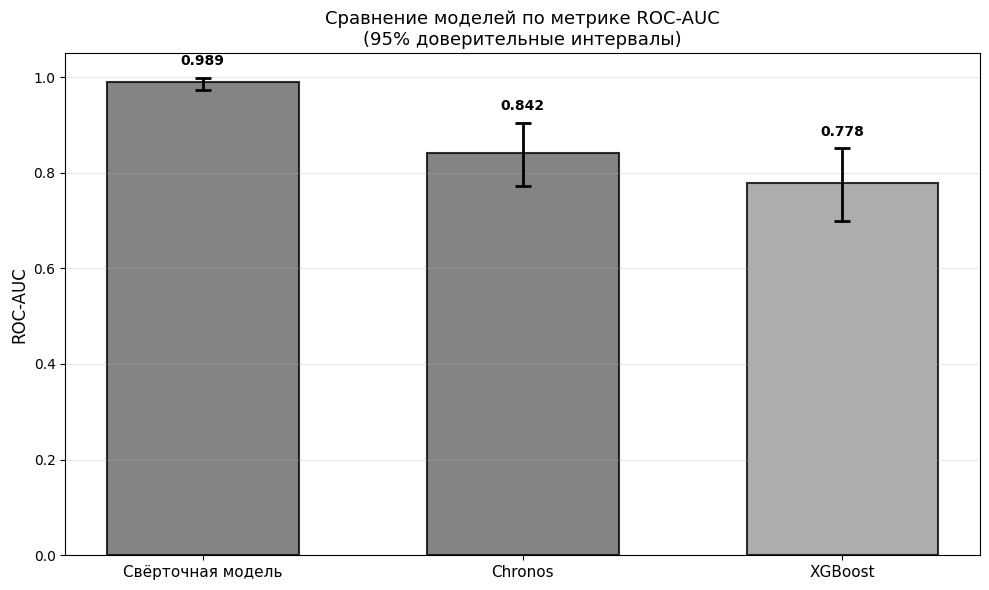

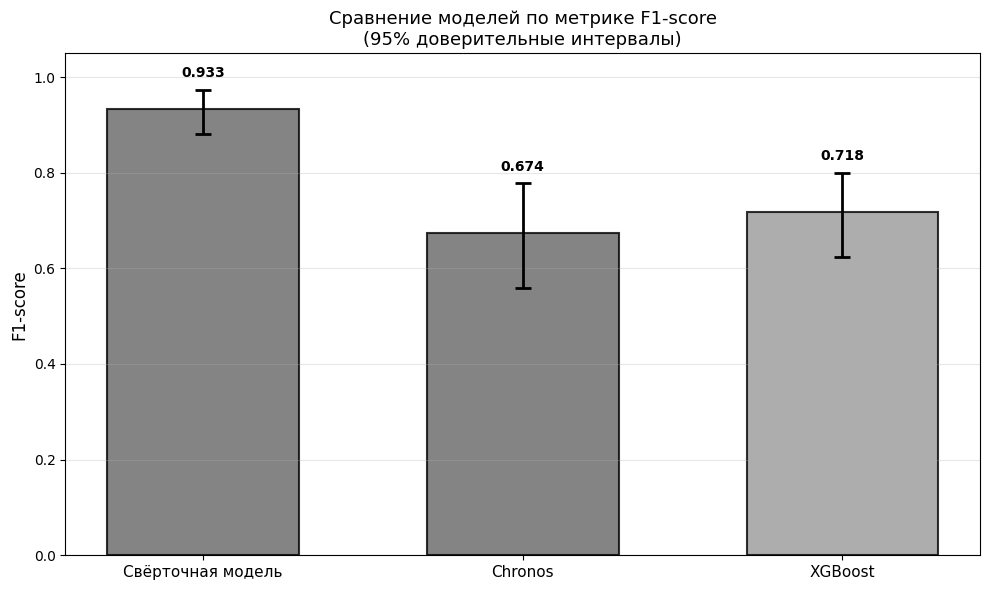

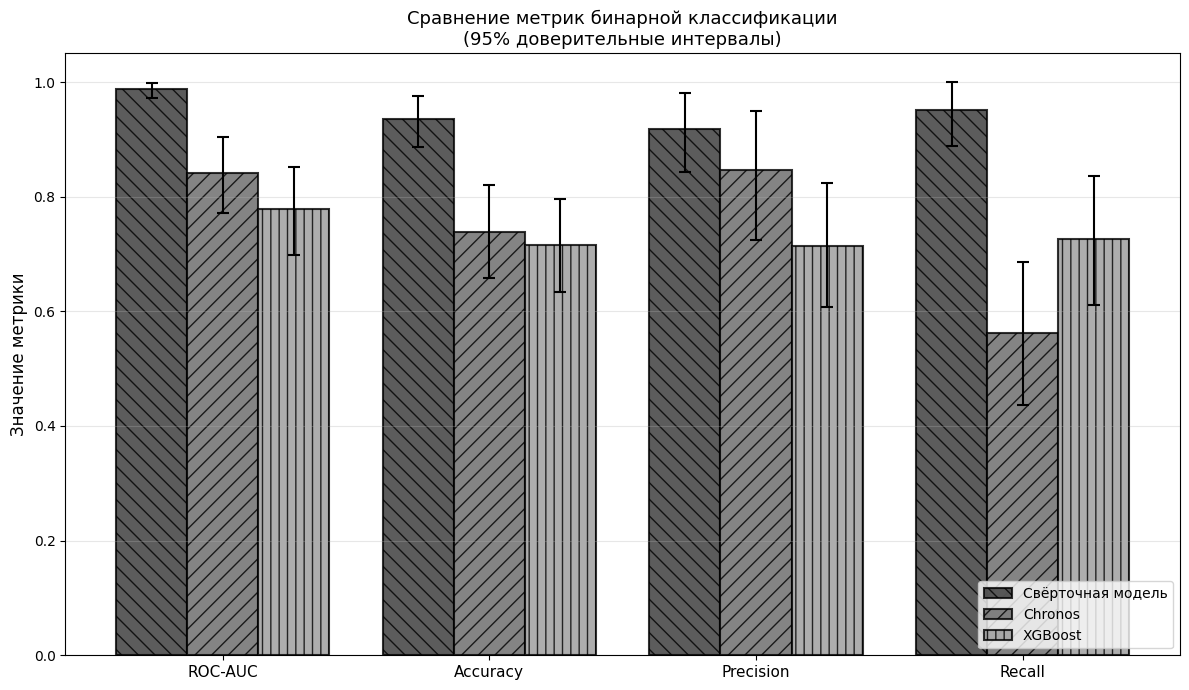

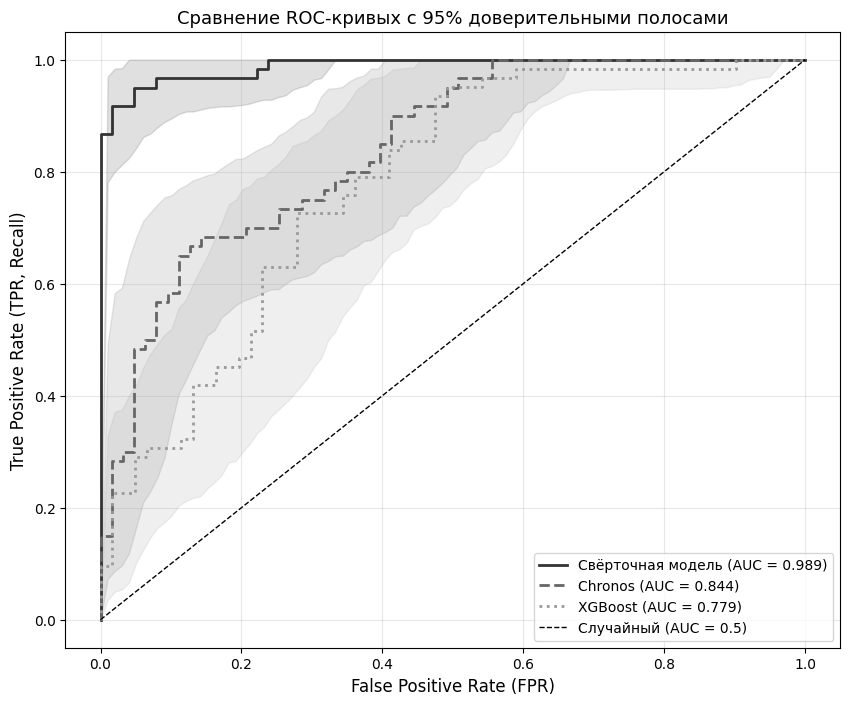

           Модель              ROC_AUC             Accuracy            Precision               Recall
Свёрточная модель 0.989 [0.973, 0.998] 0.935 [0.886, 0.976] 0.918 [0.844, 0.981] 0.951 [0.889, 1.000]
          Chronos 0.842 [0.771, 0.905] 0.738 [0.659, 0.821] 0.847 [0.725, 0.950] 0.563 [0.436, 0.687]
          XGBoost 0.778 [0.699, 0.851] 0.715 [0.634, 0.797] 0.713 [0.607, 0.824] 0.725 [0.611, 0.836]


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, 
    precision_score, recall_score, f1_score, confusion_matrix
)

def mean_absolute_percentage_error(y_true, y_pred, epsilon=1e-8):
    mask = np.abs(y_true) < epsilon
    y_true = np.where(mask, epsilon, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def bootstrap_binary_metrics(model, DEVICE, loader, n_bootstrap=1000, ci_percentile=95, logging=True):
    """
    Бутстрап для бинарного классификатора.
    
    Args:
        model: модель с выходом [batch] (вероятности)
        DEVICE: устройство
        loader: DataLoader с тестовыми данными
        n_bootstrap: количество бутстрап-итераций
        ci_percentile: доверительный уровень
        logging: печатать прогресс
    
    Returns:
        dict: метрики с доверительными интервалами
    """
    model.eval()
    
    # ========== 1. СБОР ВСЕХ ПРЕДСКАЗАНИЙ ==========
    all_targets = []
    all_probas = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            probas = model(x_batch).cpu().numpy()
            
            if probas.ndim == 2:
                probas = probas.flatten()
            
            all_targets.append(y_batch.numpy())
            all_probas.append(probas)
    
    y_true = np.concatenate(all_targets, axis=0).flatten()
    y_proba = np.concatenate(all_probas, axis=0).flatten()
    n = len(y_true)
    y_pred = (y_proba >= 0.5).astype(int)
    
    # ========== 2. ТОЧЕЧНЫЕ ОЦЕНКИ ==========
    point_metrics = {
        'ROC_AUC': roc_auc_score(y_true, y_proba),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }
    
    # Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    
    if logging:
        print("\n" + "=" * 60)
        print("ТОЧЕЧНЫЕ ОЦЕНКИ")
        print("=" * 60)
        for name, val in point_metrics.items():
            print(f"  {name}: {val:.4f}")
        print("\n  Матрица ошибок:")
        print(f"    TP = {cm[1,1]}, FP = {cm[0,1]}")
        print(f"    FN = {cm[1,0]}, TN = {cm[0,0]}")
        print("=" * 60)
    
    # ========== 3. БУТСТРАП ==========
    np.random.seed(42)
    
    bootstrap_samples = {name: [] for name in point_metrics.keys()}
    
    if logging:
        print(f"\nБутстрап: 0/{n_bootstrap}", end="")
    
    for boot_iter in range(n_bootstrap):
        indices = np.random.choice(n, size=n, replace=True)
        y_true_boot = y_true[indices]
        y_proba_boot = y_proba[indices]
        y_pred_boot = (y_proba_boot >= 0.5).astype(int)
        
        bootstrap_samples['ROC_AUC'].append(roc_auc_score(y_true_boot, y_proba_boot))
        bootstrap_samples['Accuracy'].append(accuracy_score(y_true_boot, y_pred_boot))
        bootstrap_samples['Precision'].append(precision_score(y_true_boot, y_pred_boot, zero_division=0))
        bootstrap_samples['Recall'].append(recall_score(y_true_boot, y_pred_boot, zero_division=0))
        bootstrap_samples['F1'].append(f1_score(y_true_boot, y_pred_boot, zero_division=0))
        
        if logging and (boot_iter + 1) % 100 == 0:
            print(f"\rБутстрап: {boot_iter + 1}/{n_bootstrap}", end="")
    
    if logging:
        print()
    
    # ========== 4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ==========
    alpha = (100 - ci_percentile) / 2
    results = {'point_metrics': point_metrics, 'bootstrap_samples': bootstrap_samples}
    
    for name in point_metrics.keys():
        values = np.array(bootstrap_samples[name])
        results[name] = {
            'mean': np.mean(values),
            'std': np.std(values, ddof=1),
            'ci_lower': np.percentile(values, alpha),
            'ci_upper': np.percentile(values, 100 - alpha)
        }
    
    # ========== 5. ВЫВОД ==========
    if logging:
        print(f"\n{'='*60}")
        print(f"ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (95% CI, {n_bootstrap} итераций)")
        print(f"{'='*60}")
        for name, val in results.items():
            if name in ['point_metrics', 'bootstrap_samples']:
                continue
            m = val
            p = point_metrics[name]
            print(f"  {name}:")
            print(f"    Точечная:   {p:.4f}")
            print(f"    Средняя:    {m['mean']:.4f}")
            print(f"    95% CI:     [{m['ci_lower']:.4f}, {m['ci_upper']:.4f}]")
            print(f"    Стд.откл.:  {m['std']:.4f}")
        print("=" * 60)
    
    return results, y_true, y_proba


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 1. ФУНКЦИЯ ДЛЯ СБОРА МЕТРИК (аналог регрессионной)
# ============================================================

def collect_binary_metrics(results, model_name):
    """
    Приводит результаты бутстрапа к формату для графиков.
    
    Args:
        results: результат bootstrap_binary_metrics (словарь с метриками)
        model_name: имя модели ('CNN', 'Transformer', 'XGBoost')
    
    Returns:
        dict: {'metrics': {metric: {'mean':, 'ci_lower':, 'ci_upper':}, ...}, 'name': model_name}
    """
    metrics = {}
    for metric in ['ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1']:
        metrics[metric] = {
            'mean': results[metric]['mean'],
            'ci_lower': results[metric]['ci_lower'],
            'ci_upper': results[metric]['ci_upper']
        }
    return {'metrics': metrics, 'name': model_name}


# ============================================================
# 2. СРАВНИТЕЛЬНЫЙ ГРАФИК МЕТРИК (как в регрессии)
# ============================================================

def plot_binary_comparison(models_results, metric='ROC_AUC', figsize=(10, 6), save_path=None):
    """
    Сравнение бинарных классификаторов по выбранной метрике.
    
    Args:
        models_results: список словарей от collect_binary_metrics
        metric: 'ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1'
        figsize: размер графика
        save_path: путь для сохранения
    """
    model_names = [r['name'] for r in models_results]
    means = [r['metrics'][metric]['mean'] for r in models_results]
    ci_lower = [r['metrics'][metric]['ci_lower'] for r in models_results]
    ci_upper = [r['metrics'][metric]['ci_upper'] for r in models_results]
    
    x = np.arange(len(model_names))
    width = 0.6
    
    # Цвета для ч/б печати
    colors = {'CNN': '#333333', 'Transformer': '#666666', 'XGBoost': '#999999'}
    bar_colors = [colors.get(name, '#666666') for name in model_names]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    bars = ax.bar(x, means, width, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    for i, (bar, low, up, mean) in enumerate(zip(bars, ci_lower, ci_upper, means)):
        ax.errorbar(i, mean, yerr=[[mean - low], [up - mean]],
                    fmt='none', c='black', capsize=6, capthick=2, linewidth=2)
        ax.text(i, up + 0.02, f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    metric_names = {
        'ROC_AUC': 'ROC-AUC',
        'Accuracy': 'Accuracy',
        'Precision': 'Precision',
        'Recall': 'Recall',
        'F1': 'F1-score'
    }
    
    ax.set_ylabel(metric_names.get(metric, metric), fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Сравнение моделей по метрике {metric_names.get(metric, metric)}\n(95% доверительные интервалы)', fontsize=13)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================
# 3. СВОДНАЯ ТАБЛИЦА МЕТРИК (как в регрессии)
# ============================================================

def plot_all_metrics_comparison(models_results, figsize=(12, 7), save_path=None):
    """
    Сравнение всех метрик для нескольких моделей (сгруппированные столбцы).
    """
    metrics = ['ROC_AUC', 'Accuracy', 'Precision', 'Recall']
    model_names = [r['name'] for r in models_results]
    n_models = len(model_names)
    n_metrics = len(metrics)
    
    x = np.arange(n_metrics)
    width = 0.8 / n_models
    
    colors = {'Свёрточная модель': '#333333', 'Chronos': '#666666', 'XGBoost': '#999999'}
    hatches = {'Свёрточная модель': '\\\\', 'Chronos': '//', 'XGBoost': '||'}
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, model_result in enumerate(models_results):
        model_name = model_result['name']
        means = [model_result['metrics'][m]['mean'] for m in metrics]
        ci_lower = [model_result['metrics'][m]['ci_lower'] for m in metrics]
        ci_upper = [model_result['metrics'][m]['ci_upper'] for m in metrics]
        
        offset = (i - (n_models - 1) / 2) * width
        bars = ax.bar(x + offset, means, width, label=model_name,
                      color=colors.get(model_name, '#666666'), alpha=0.8,
                      edgecolor='black', linewidth=1.5,
                      hatch=hatches.get(model_name, ''))
        
        for j, (bar, low, up, mean) in enumerate(zip(bars, ci_lower, ci_upper, means)):
            ax.errorbar(bar.get_x() + bar.get_width() / 2, mean,
                        yerr=[[mean - low], [up - mean]],
                        fmt='none', c='black', capsize=4, capthick=1.5, linewidth=1.5)
    
    metric_names = {
        'ROC_AUC': 'ROC-AUC',
        'Accuracy': 'Accuracy',
        'Precision': 'Precision',
        'Recall': 'Recall',
    
    }
    
    ax.set_xticks(x)
    ax.set_xticklabels([metric_names[m] for m in metrics], fontsize=11)
    ax.set_ylabel('Значение метрики', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_title('Сравнение метрик бинарной классификации\n(95% доверительные интервалы)', fontsize=13)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================
# 4. ROC-КРИВЫЕ ДЛЯ НЕСКОЛЬКИХ МОДЕЛЕЙ
# ============================================================

def plot_roc_with_ci(y_true, y_proba, n_bootstrap=1000, ci_percentile=95, 
                     color='steelblue', label='Model', linewidth=2, save_path=None):
    """
    ROC-кривая с доверительным интервалом (бутстрап).
    
    Args:
        y_true: истинные метки
        y_proba: предсказанные вероятности
        n_bootstrap: количество бутстрап-итераций
        ci_percentile: доверительный уровень
        color: цвет линии
        label: подпись модели
        linewidth: толщина линии
        save_path: путь для сохранения
    """
    n = len(y_true)
    np.random.seed(42)
    
    # ROC-кривая на всех данных
    fpr_mean, tpr_mean, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    
    # Бутстрап для ROC-кривой
    fpr_grid = np.linspace(0, 1, 100)
    tpr_list = []
    
    for _ in range(n_bootstrap):
        indices = np.random.choice(n, size=n, replace=True)
        y_true_boot = y_true[indices]
        y_proba_boot = y_proba[indices]
        
        fpr, tpr, _ = roc_curve(y_true_boot, y_proba_boot)
        tpr_interp = np.interp(fpr_grid, fpr, tpr)
        tpr_interp[0] = 0
        tpr_list.append(tpr_interp)
    
    tpr_list = np.array(tpr_list)
    alpha = (100 - ci_percentile) / 2
    tpr_lower = np.percentile(tpr_list, alpha, axis=0)
    tpr_upper = np.percentile(tpr_list, 100 - alpha, axis=0)
    
    plt.figure(figsize=(8, 6))
    
    # Доверительная полоса
    plt.fill_between(fpr_grid, tpr_lower, tpr_upper, 
                     alpha=0.25, color=color, label=f'{ci_percentile}% CI')
    
    # Средняя ROC-кривая
    plt.plot(fpr_mean, tpr_mean, color=color, linewidth=linewidth,
             label=f'{label} (AUC = {auc:.3f})')
    
    # Диагональ (случайный классификатор)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный (AUC = 0.5)')
    
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR, Recall)', fontsize=12)
    plt.title(f'ROC-кривая с {ci_percentile}% доверительной полосой', fontsize=13)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_roc_comparison_with_ci(models_data, n_bootstrap=1000, ci_percentile=95, 
                                 figsize=(10, 8), save_path=None):
    """
    Сравнение ROC-кривых нескольких моделей с доверительными интервалами.
    
    Args:
        models_data: список словарей [
            {'name': 'CNN', 'y_true': y_true, 'y_proba': y_proba},
            {'name': 'Transformer', 'y_true': y_true, 'y_proba': y_proba},
            ...
        ]
        n_bootstrap: количество бутстрап-итераций
        ci_percentile: доверительный уровень
        figsize: размер графика
        save_path: путь для сохранения
    """
    colors = ['#333333', '#666666', '#999999', '#CCCCCC']
    line_styles = ['-', '--', ':', '-.']
    hatches = ['', '\\\\', '//', '||']
    
    plt.figure(figsize=figsize)
    
    for idx, model in enumerate(models_data):
        name = model['name']
        y_true = model['y_true']
        y_proba = model['y_proba']
        n = len(y_true)
        np.random.seed(42 + idx)
        
        # ROC-кривая на всех данных
        fpr_mean, tpr_mean, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        
        # Бутстрап для доверительной полосы
        fpr_grid = np.linspace(0, 1, 100)
        tpr_list = []
        
        for _ in range(n_bootstrap):
            indices = np.random.choice(n, size=n, replace=True)
            y_true_boot = y_true[indices]
            y_proba_boot = y_proba[indices]
            fpr, tpr, _ = roc_curve(y_true_boot, y_proba_boot)
            tpr_interp = np.interp(fpr_grid, fpr, tpr)
            tpr_interp[0] = 0
            tpr_list.append(tpr_interp)
        
        tpr_list = np.array(tpr_list)
        alpha = (100 - ci_percentile) / 2
        tpr_lower = np.percentile(tpr_list, alpha, axis=0)
        tpr_upper = np.percentile(tpr_list, 100 - alpha, axis=0)
        
        color = colors[idx % len(colors)]
        linestyle = line_styles[idx % len(line_styles)]
        
        # Доверительная полоса
        plt.fill_between(fpr_grid, tpr_lower, tpr_upper, 
                         alpha=0.15, color=color)
        
        # ROC-кривая
        plt.plot(fpr_mean, tpr_mean, color=color, linestyle=linestyle, 
                 linewidth=2, label=f'{name} (AUC = {auc:.3f})')
    
    # Диагональ
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный (AUC = 0.5)')
    
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR, Recall)', fontsize=12)
    plt.title(f'Сравнение ROC-кривых с {ci_percentile}% доверительными полосами', fontsize=13)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_roc_curves_comparison(models_roc_data, figsize=(10, 8), save_path=None):
    """
    Сравнение ROC-кривых нескольких моделей.
    
    Args:
        models_roc_data: список словарей [{'name': 'CNN', 'y_true': y_true, 'y_proba': y_proba}, ...]
    """
    colors = {'CNN': '#333333', 'Transformer': '#666666', 'XGBoost': '#999999'}
    line_styles = {'CNN': '-', 'Transformer': '--', 'XGBoost': ':'}
    
    plt.figure(figsize=figsize)
    
    for model_data in models_roc_data:
        name = model_data['name']
        y_true = model_data['y_true']
        y_proba = model_data['y_proba']
        
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        
        plt.plot(fpr, tpr, color=colors.get(name, '#666666'), 
                 linestyle=line_styles.get(name, '-'), linewidth=2,
                 label=f'{name} (AUC = {auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный (AUC = 0.5)')
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR, Recall)', fontsize=12)
    plt.title('ROC-кривые: сравнение моделей', fontsize=13)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================
# 5. ТАБЛИЦА ДЛЯ ДИПЛОМА
# ============================================================

def create_binary_comparison_table(models_results):
    """
    Создаёт DataFrame со сравнительной таблицей метрик.
    """
    import pandas as pd
    
    data = []
    for r in models_results:
        row = {'Модель': r['name']}
        for metric in ['ROC_AUC', 'Accuracy', 'Precision', 'Recall']:
            m = r['metrics'][metric]
            row[metric] = f"{m['mean']:.3f} [{m['ci_lower']:.3f}, {m['ci_upper']:.3f}]"
        data.append(row)
    
    df = pd.DataFrame(data)
    return df


# ============================================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ
# ============================================================
    # ===== 1. ПОЛУЧАЕМ РЕЗУЛЬТАТЫ ДЛЯ КАЖДОЙ МОДЕЛИ =====
    # Уже есть:
from utils import load_model_with_architecture
model_cnn = load_model_with_architecture("inference_ready_weights/best_h2a_conv.pkl",'cpu')
model_trans = load_model_with_architecture("inference_ready_weights/best_h2a_transformer.pkl",'cpu')
results_cnn, y_true_cnn, y_proba_cnn = bootstrap_binary_metrics(model_cnn, 'cpu', val_loader)
results_trans, y_true_trans, y_proba_trans = bootstrap_binary_metrics(model_trans, 'cpu', val_loader)
    
    # ===== 2. ПРИВОДИМ К ФОРМАТУ ДЛЯ ГРАФИКОВ =====
models_results = [
        collect_binary_metrics(results_cnn, 'Свёрточная модель'),
        collect_binary_metrics(results_trans, 'Chronos'),
        collect_binary_metrics(boot, "XGBoost")
    ]
    
    # ===== 3. ГРАФИКИ =====
# Отдельный график для ROC-AUC
plot_binary_comparison(models_results, metric='ROC_AUC', save_path='binary_roc_auc.png')

# Отдельный график для F1
plot_binary_comparison(models_results, metric='F1', save_path='binary_f1.png')

# Все метрики на одном графике (сгруппированные столбцы)
plot_all_metrics_comparison(models_results, save_path='binary_all_metrics.png')

# ROC-кривые
models_roc_data = [
    {'name': 'Свёрточная модель', 'y_true': y_true_cnn, 'y_proba': y_proba_cnn},
    {'name': 'Chronos', 'y_true': y_true_trans, 'y_proba': y_proba_trans},
    {'name': 'XGBoost', 'y_true': y_test, 'y_proba': y_pred_prob}
]
plot_roc_comparison_with_ci(models_roc_data, save_path='binary_roc_comparison.png')

# ===== 4. ТАБЛИЦА =====
df = create_binary_comparison_table(models_results)
print(df.to_string(index=False))
df.to_csv('binary_comparison_table.csv', index=False)

In [ ]:
plot_binary_comparison(models_results, metric='ROC_AUC', save_path='binary_roc_auc.png')

# Отдельный график для F1
plot_binary_comparison(models_results, metric='F1', save_path='binary_f1.png')

# Все метрики на одном графике (сгруппированные столбцы)
plot_all_metrics_comparison(models_results, save_path='binary_all_metrics.png')

# ROC-кривые
models_roc_data = [
    {'name': 'CNN', 'y_true': y_true_cnn, 'y_proba': y_proba_cnn},
    {'name': 'Transformer', 'y_true': y_true_trans, 'y_proba': y_proba_trans}
]
plot_roc_comparison_with_ci(models_roc_data, save_path='binary_roc_comparison.png')

# ===== 4. ТАБЛИЦА =====
df = create_binary_comparison_table(models_results)
print(df.to_string(index=False))
df.to_csv('binary_comparison_table.csv', index=False)

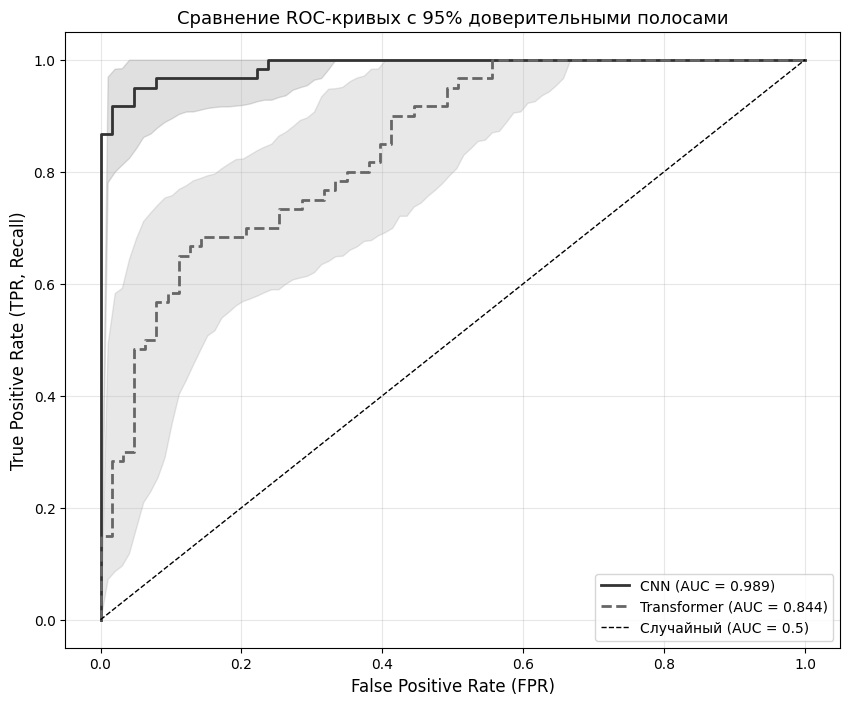

     Модель              ROC_AUC             Accuracy            Precision               Recall                   F1
        CNN 0.989 [0.973, 0.998] 0.935 [0.886, 0.976] 0.918 [0.844, 0.981] 0.951 [0.889, 1.000] 0.933 [0.881, 0.974]
Transformer 0.842 [0.771, 0.905] 0.738 [0.659, 0.821] 0.847 [0.725, 0.950] 0.563 [0.436, 0.687] 0.674 [0.559, 0.778]


In [20]:
plot_roc_comparison_with_ci(models_roc_data, save_path='binary_roc_comparison.png')

# ===== 4. ТАБЛИЦА =====
df = create_binary_comparison_table(models_results)
print(df.to_string(index=False))
df.to_csv('binary_comparison_table.csv', index=False)

проверка conv для msw

In [22]:
dataset

[{'V': array([-5. , -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4.3, -4.2, -4.1, -4. ,
         -3.9, -3.8, -3.7, -3.6, -3.5, -3.4, -3.3, -3.2, -3.1, -3. , -2.9,
         -2.8, -2.7, -2.6, -2.5, -2.4, -2.3, -2.2, -2.1, -2. , -1.9, -1.8,
         -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1. , -0.9, -0.8, -0.7,
         -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,
          0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,  1.2,  1.3,  1.4,  1.5,
          1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,  2.3,  2.4,  2.5,  2.6,
          2.7,  2.8,  2.9,  3. ,  3.1,  3.2,  3.3,  3.4,  3.5,  3.6,  3.7,
          3.8,  3.9,  4. ,  4.1,  4.2,  4.3,  4.4,  4.5,  4.6,  4.7,  4.8,
          4.9,  5. ]),
  'FullAbs': array([1.23665e-03, 1.17627e-03, 1.12171e-03, 1.07337e-03, 1.03240e-03,
         1.00113e-03, 9.83338e-04, 9.84086e-04, 1.00870e-03, 1.06054e-03,
         1.13807e-03, 1.23235e-03, 1.32668e-03, 1.39922e-03, 1.42854e-03,
         1.40032e-03, 1.31294e-03, 1.17880e-03, 1.02051e-03, 8.6

In [1]:
# После того как получил предсказания для CNN и Transformer
# Добавь XGBoost
import xgboost as xgb
from pathlib import Path
from scipy import stats, signal
from scipy.interpolate import interp1d
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel

from chronos import ChronosPipeline
import torch
import torch.nn as nn

def parse_parameters(file_path):
    """
    Читает файл parameters.txt и возвращает словарь с нужными параметрами
    """
    params = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                key = parts[0]
                value = ' '.join(parts[1:])  # на случай, если значение содержит пробелы
                params[key] = value
    # Извлекаем нужные параметры
    result = {}
    for param in ['PName', 'Msw', 'XUVInt', 'H2a', 'Helium']:
        result[param] = params.get(param)
    return result

def process_files_in_folder_with_params(root_folder):
    """
    Рекурсивно проходит по папке, читает параметры и файлы с данными
    Возвращает список словарей, где каждый словарь — это один файл
    """
    dataset = []
    root = Path(root_folder)
    for data_file_path in root.rglob('*[.txt,.dat]'):
        if data_file_path.name == 'parameters.txt':
            continue  # Пропускаем файл параметров

        # Ищем файл parameters.txt в той же папке
        param_file_path = data_file_path.parent / 'parameters.txt'

        if param_file_path.exists():
            params = parse_parameters(param_file_path)
            # print(f"Файл: {data_file_path}")
            # print(f"Параметры: {params}")
        else:
            # print(f"Файл parameters.txt не найден для {data_file_path}")
            params = {}

        # Читаем V и FullAbs из data файла
        try:
            V, FullAbs = np.loadtxt(data_file_path, usecols=(0, 1), unpack=True, skiprows=1)
            entry = {
                'V': V,
                'FullAbs': FullAbs,
                'PName': params.get('PName'),
                'Msw': params.get('Msw'),
                'XUVInt': params.get('XUVInt'),
                'H2a': params.get('H2a'),
                'Helium': params.get('Helium'),
                # 'File': str(data_file_path)  # можно убрать, если не нужно
            }
            dataset.append(entry)
        except Exception as e:
            print(f"Ошибка при загрузке данных из {data_file_path}: {e}")
        # print("-" * 50)

    return dataset


def compute_basic_stats(arr):
    return {
        # 'min': np.min(arr),
        # 'max': np.max(arr),
        # 'mean': np.mean(arr),
        # 'median': np.median(arr),
        # 'std': np.std(arr),
        # 'var': np.var(arr),
        'skew': stats.skew(arr),
        'kurt': stats.kurtosis(arr)
    }

def compute_peak_features(x, y):
    # global peak
    idx_max = np.argmax(y)
    peak_x = x[idx_max]
    peak_y = y[idx_max]
    # FWHM: find x positions where y >= half max
    half = peak_y / 2.0
    # interpolate to get better precision
    f = interp1d(x, y - half, kind='linear')
    try:
        roots = np.sort(np.unique(np.hstack((np.where(np.sign(y-half)==0)[0]))))
        # simpler approach: find approximate left/right crossing by index
        left_idx = np.where(y[:idx_max] <= half)[0]
        right_idx = np.where(y[idx_max:] <= half)[0]
        if left_idx.size>0:
            left = np.interp(half, y[left_idx[-1]:left_idx[-1]+2], x[left_idx[-1]:left_idx[-1]+2])
        else:
            left = x[0]
        if right_idx.size>0:
            rbase = idx_max + right_idx[0]
            right = np.interp(half, y[rbase:rbase+2], x[rbase:rbase+2]) if rbase+1 < len(x) else x[-1]
        else:
            right = x[-1]
        fwhm = right - left
    except Exception:
        # fallback discrete
        indices = np.where(y >= half)[0]
        if indices.size>0:
            fwhm = x[indices[-1]] - x[indices[0]]
        else:
            fwhm = np.nan
    return {
        'peak_x': float(peak_x),
        'peak_y': float(peak_y),
        'fwhm': float(fwhm)
    }


def extract_features_from_profile(x, y):
    feats = {}
    # feats.update({'len': len(y)})
    # feats.update({f'Q_{q}': float(np.percentile(y, q)) for q in [1,5,25,50,75,95,99]})
    feats.update(compute_basic_stats(y))
    feats.update(compute_peak_features(x, y))
    # fft_feats, spec = compute_spectral_features(y, ncoef=6)
    # feats.update(fft_feats)
    # feats.update(spec)
    # feats.update(compute_derivative_features(x, y))
    # feats.update(compute_autocorr_features(y, lags=[1,2,5]))
    # AUC
    # feats['auc'] = float(np.trapz(y, x))
    # # left/center/right areas relative to peak
    # idx_max = np.argmax(y)
    # left_area = float(np.trapz(y[:idx_max+1], x[:idx_max+1])) if idx_max>0 else 0.0
    # right_area = float(np.trapz(y[idx_max:], x[idx_max:])) if idx_max < len(y)-1 else 0.0
    # feats['left_area'] = left_area
    # feats['right_area'] = right_area
    # feats['center_area_ratio'] = (feats['auc'] - left_area - right_area) / feats['auc'] if feats['auc']>0 else 0.0
    return feats


def analyze_dataframe(df):
    """
    Принимает DataFrame с колонками V, FullAbs и параметрами.
    Возвращает новый DataFrame: один объект = один профиль со всеми признаками.
    """
    rows = []

    for idx, row in df.iterrows():
        x = np.array(row['V'])
        y = np.array(row['FullAbs'])

        # Извлекаем признаки профиля
        feats = extract_features_from_profile(x, y)

        # Добавляем исходные параметры
        feats["FullAbs"] = y
        feats['Msw'] = row.get('Msw')
        feats['XUVInt'] = row.get('XUVInt')
        feats['Planet'] = row.get('PName')
        feats['H2a'] = row.get('H2a')
        feats['Helium'] = row.get('Helium')

        # feats['Msw'] = np.log1p(feats['Msw'].values.astype(np.float32))
        # feats['XUVInt'] = feats['XUVInt'].values.astype(np.float32)
        # feats['Helium'] = feats['Helium'].values.astype(np.float32)

        rows.append(feats)

    return pd.DataFrame(rows)
df = pd.read_parquet('dataset.parquet')
dataset = analyze_dataframe(df)
dataset['Msw'] = np.log1p(dataset['Msw'].values.astype(np.float32))
# dataset['Msw'] = dataset['Msw'].values.astype(np.float32)

dataset['XUVInt'] = dataset['XUVInt'].values.astype(np.float32)
dataset['Helium'] = dataset['Helium'].values.astype(np.float32)
dataset
feature_names = ['skew', 'kurt', 'peak_x', 'peak_y', 'fwhm']
X = dataset[feature_names].values.astype(np.float32)
y = dataset['H2a'].values.astype(np.float32)
print(f"Распределение классов:\n{pd.Series(y).value_counts()}")
print(f"{'='*50}\n")
from sklearn.model_selection import train_test_split

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Обучение модели XGBoost
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # учёт дисбаланса
    random_state=42,
    use_label_encoder=False
)

model.fit(X_train, y_train)

# Предсказания
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred_binary = (y_pred_prob >= 0.5).astype(int)

# Базовые метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print(f"Accuracy:  {accuracy_score(y_test, y_pred_binary):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_binary):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_binary):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_binary):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_prob):.4f}")

# Матрица ошибок
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_binary))

# Бутстреп для доверительных интервалов
def bootstrap_metrics(y_true, y_proba, n=1000):
    metrics = {'AUC': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
    for _ in range(n):
        idx = np.random.choice(len(y_true), len(y_true), replace=True)
        y_true_boot = y_true[idx]
        y_proba_boot = y_proba[idx]
        y_pred_boot = (y_proba_boot >= 0.5).astype(int)
        
        metrics['AUC'].append(roc_auc_score(y_true_boot, y_proba_boot))
        metrics['Accuracy'].append(accuracy_score(y_true_boot, y_pred_boot))
        metrics['Precision'].append(precision_score(y_true_boot, y_pred_boot, zero_division=0))
        metrics['Recall'].append(recall_score(y_true_boot, y_pred_boot, zero_division=0))
        metrics['F1'].append(f1_score(y_true_boot, y_pred_boot, zero_division=0))
    
    result = {}
    for k, v in metrics.items():
        result[k] = {'mean': np.mean(v), 'std': np.std(v), 
                     'ci_lower': np.percentile(v, 2.5), 'ci_upper': np.percentile(v, 97.5)}
    return result

# Запуск бутстрепа
boot = bootstrap_metrics(y_test, y_pred_prob)

# Предсказания
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred_binary = (y_pred_prob >= 0.5).astype(int)

# Базовые метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print(f"Accuracy:  {accuracy_score(y_test, y_pred_binary):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_binary):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_binary):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_binary):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_prob):.4f}")

# Матрица ошибок
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_binary))

# Бутстреп для доверительных интервалов
def bootstrap_metrics(y_true, y_proba, n=1000):
    metrics = {'ROC_AUC': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
    for _ in range(n):
        idx = np.random.choice(len(y_true), len(y_true), replace=True)
        y_true_boot = y_true[idx]
        y_proba_boot = y_proba[idx]
        y_pred_boot = (y_proba_boot >= 0.5).astype(int)
        
        metrics['ROC_AUC'].append(roc_auc_score(y_true_boot, y_proba_boot))
        metrics['Accuracy'].append(accuracy_score(y_true_boot, y_pred_boot))
        metrics['Precision'].append(precision_score(y_true_boot, y_pred_boot, zero_division=0))
        metrics['Recall'].append(recall_score(y_true_boot, y_pred_boot, zero_division=0))
        metrics['F1'].append(f1_score(y_true_boot, y_pred_boot, zero_division=0))
    
    result = {}
    for k, v in metrics.items():
        result[k] = {'mean': np.mean(v), 'std': np.std(v), 
                     'ci_lower': np.percentile(v, 2.5), 'ci_upper': np.percentile(v, 97.5)}
    return result

# Запуск бутстрепа
boot = bootstrap_metrics(y_test, y_pred_prob)

collect_binary_metrics(boot, 'XGBoost'),


/home/kirill/diploma/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Распределение классов:
1.0    309
0.0    305
Name: count, dtype: int64



/home/kirill/diploma/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [04:39:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy:  0.7154
Precision: 0.7143
Recall:    0.7258
F1:        0.7200
ROC-AUC:   0.7790

Confusion Matrix:
[[43 18]
 [17 45]]


KeyboardInterrupt: 

In [23]:
df

,Модель,ROC_AUC,Accuracy,Precision,Recall
0,CNN,"0.989 [0.973, 0.998]","0.935 [0.886, 0.976]","0.918 [0.844, 0.981]","0.951 [0.889, 1.000]"
1,Transformer,"0.842 [0.771, 0.905]","0.738 [0.659, 0.821]","0.847 [0.725, 0.950]","0.563 [0.436, 0.687]"


In [ ]:
def testing_model(loader, logging = False, save=False):
    model.eval()
    all_preds_scaled = []
    all_targets_scaled = []

    # Собираем все предсказания и истинные значения
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_pred = model(x_batch)
            all_preds_scaled.append(y_pred.cpu())
            all_targets_scaled.append(y_batch.cpu())

    # Конкатенация
    y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
    y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

    # Денормализация → исходные физические шкалы
    y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
    y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


    # Имена целевых переменных (в том же порядке, что и в Y)
    # target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
    target_names = ['log(Msw)']
    if logging:
        print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

    for i, name in enumerate(target_names):
        mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
        mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
        rmse = np.sqrt(mse)
        # Относительная MSE (RelMSE) - (pred/true - 1)^2
        # Защита от деления на ноль
        epsilon = 1e-7
        true_values = np.abs(y_true_orig[:, i]) + epsilon
        rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

        # Можно также считать в процентах
        rel_mse_percent = rel_mse * 100

        # Дополнительно: средняя относительная ошибка в процентах (MAPE)
        mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100

        if logging:
            print(f"{name}:")
            print(f"  MAE:  {mae:.4f}")
            print(f"  MSE:  {mse:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
            print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
            print(f"  MAPE:     {mape:.4f}%")
            print("-" * 30)
        if save:
            # print('DSAFDASF')
            match name:
                case "(XUVInt)":
                    metrics_xuv.append(mape)
                    if mape <= min(metrics_xuv):
                        save_model_with_architecture(model, "best_xuv.pkl")
                case "log(Msw)":
                    metrics_masslos.append(mape)
                    if mape <= min(metrics_masslos):
                        save_model_with_architecture(model, "best_msw.pkl")
                case "(Helium)":
                    metrics_helium.append(mape)
                    if mape <= min(metrics_xuv):
                        save_model_with_architecture(model, "best_helium.pkl")
        print("epoch mape", mape)
        return mape

# ----- ОБУЧЕНИЕ -----
val_losses = []
train_losses = []

mape_train = []
mape_val = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        x_batch = augment_spectrum_noise_and_sharpen(x_batch)

        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Валидация
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            x_batch = augment_spectrum_noise_and_sharpen(x_batch)
            preds = model(x_batch)
            val_loss += criterion(preds, y_batch).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.6f} | "
          f"Val Loss: {avg_val_loss:.6f}")
    scheduler.step(avg_val_loss)
    val_losses.append(avg_val_loss)
    train_losses.append(avg_train_loss)
   

    mape_val.append(testing_model(val_loader, save=True))
    mape_train.append(testing_model(train_loader))
    
# ----------------------------
# 5. ИНФЕРЕНС (пример)
# ----------------------------
print('-'*30)
def smart_format(x, precision=4):
    if abs(x) >= 1e9:
        # Для больших чисел — оставляем как есть, но с фикс. точностью
        return f"{x:.{precision}f}"
    elif abs(x) < 1e-3 and x != 0:
        return f"{x:.{precision}e}"
    else:
        return f"{x:.{precision}f}"

def format_smart_array(arr, precision=4):
    return "[" + ", ".join(smart_format(x, precision) for x in arr) + "]"




with torch.no_grad():
    # Берём последний пример из валидации
    x_input = torch.tensor(X_val[-1:], dtype=torch.float32).to(DEVICE)  # [1, 100]
    y_true_scaled = Y_val[-1:]  # [1, 3] — НОРМАЛИЗОВАННЫЙ GT

    # Предсказание (в нормализованных шкалах)
    y_pred_scaled = model(x_input)  # [1, 3]

    # Денормализация
    y_true_original = y_scaler.inverse_transform(y_true_scaled)  # [1, 3]
    y_pred_original = y_scaler.inverse_transform(y_pred_scaled.cpu().numpy())   # [1, 3]

    # Вывод
    print("Ground Truth (original):", format_smart_array(y_true_original.flatten()))
    print("Prediction   (original):", format_smart_array(y_pred_original.flatten()))

    # Метрики в исходных шкалах
    mae = mean_absolute_error(y_true_original, y_pred_original)
    mse = mean_squared_error(y_true_original, y_pred_original)
    rmse = np.sqrt(mse)

    print(f"\nMetrics (original scale):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")



model.eval()
all_preds_scaled = []
all_targets_scaled = []

# Собираем все предсказания и истинные значения
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(DEVICE)
        y_pred = model(x_batch)
        all_preds_scaled.append(y_pred.cpu())
        all_targets_scaled.append(y_batch.cpu())

# Конкатенация
y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

# Денормализация → исходные физические шкалы
y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


# Имена целевых переменных (в том же порядке, что и в Y)
# target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
target_names = ['(XUVInt)']

print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
    mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
    rmse = np.sqrt(mse)
    # Относительная MSE (RelMSE) - (pred/true - 1)^2
    # Защита от деления на ноль
    epsilon = 1e-7
    true_values = np.abs(y_true_orig[:, i]) + epsilon
    rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

    # Можно также считать в процентах
    rel_mse_percent = rel_mse * 100

    # Дополнительно: средняя относительная ошибка в процентах (MAPE)
    mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100
    ss_res = np.sum((y_true_orig[:, i] - y_pred_orig[:, i]) ** 2)
    ss_tot = np.sum((y_true_orig[:, i] - np.mean(y_true_orig[:, i])) ** 2)
    r2 = 1 - (ss_res / (ss_tot + epsilon))

    print(f"{name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
    print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
    print(f"  MAPE:     {mape:.4f}%")
    print(f"  R²:       {r2:.4f}")
    print("-" * 30)

ChronosRegressor(
  (encoder): PeftModelForFeatureExtraction(
    (base_model): LoraModel(
      (model): T5Stack(
        (embed_tokens): Embedding(4096, 512)
        (block): ModuleList(
          (0): T5Block(
            (layer): ModuleList(
              (0): T5LayerSelfAttention(
                (SelfAttention): T5Attention(
                  (q): lora.Linear(
                    (base_layer): Linear(in_features=512, out_features=512, bias=False)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=512, out_features=2, bias=False)
                    )
                    (lora_B): ModuleDict(
                      (default): Linear(in_features=2, out_features=512, bias=False)
                    )
                    (lora_embedding_A): ParameterDict()
                    (lora_embedding_B): ParameterDict()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import ChronosPipeline, Chronos2Pipeline
from utils import save_model_with_architecture
from peft import LoraConfig, get_peft_model, TaskType
from spectrum_augmentations import augment_spectrum_noise_and_sharpen
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=DEVICE,
    dtype=torch.float32,
)


tokenizer = pipeline.tokenizer
encoder = pipeline.model.model.encoder
def testing_model(loader, logging=True, use_oracle_metrics=True, save = False):
    model.eval()
    all_targets_scaled = []
    all_preds_selected = []   # будем собирать выбранные (по confidence) предсказания
    all_preds_heads = []      # для oracle
    best_head_statistics = []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.cpu().numpy()
            x_batch = augment_spectrum_noise_and_sharpen(x_batch)
            all_preds = model(x_batch)   # [batch, K, out_dim], [batch, K]

            # 1. Выбираем голову с максимальным confidence
            all_targets_scaled.append(y_batch)

            # 2. Для oracle сохраняем все головы
            if use_oracle_metrics:
                all_preds_heads.append(all_preds.cpu().numpy())

    # Дальше – без изменений (конкатенация, денормализация, расчёт метрик)
    y_true_scaled = np.concatenate(all_targets_scaled, axis=0)
    y_true_orig = y_scaler.inverse_transform(y_true_scaled)

    # Имена целевых переменных
    # target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
    target_names = ['(Helium)']
    # target_names = ['(XUVInt)']
    if logging:
        print("Метрики по выбранному предсказанию (max confidence):\n")

    # Словари для хранения метрик (выбранное)
    mape_oracle = {}
    # Также будем хранить oracle метрики, если нужно
    if use_oracle_metrics:
        # Объединяем все предсказания голов
        all_heads = np.concatenate(all_preds_heads, axis=0)      # [N, K, out_dim]
       
        mse_per_head = np.mean((all_heads - y_true_scaled[:, np.newaxis, :])**2, axis=2)  # [N, K]
        best_head_idx = np.argmin(mse_per_head, axis=1)          # [N]
        # best_head_statistics.append(best_head_idx)
        # Выбираем предсказания лучших голов
        best_preds = all_heads[np.arange(all_heads.shape[0]), best_head_idx]  # [N, out_dim]
        y_pred_oracle_orig = y_scaler.inverse_transform(best_preds)

        if logging:
            print("\nМетрики по лучшей голове (oracle):\n")

    # Вычисляем метрики для каждой переменной
    for i, name in enumerate(target_names):
        true_vals = y_true_orig[:, i]

        if use_oracle_metrics:
            pred_oracle = y_pred_oracle_orig[:, i]
            mape_ora = np.mean(np.abs((true_vals - pred_oracle) / (np.abs(true_vals) + 1e-7))) * 100
            if logging:
                print(f"{name} (oracle): MAPE = {mape_ora:.4f}%")
                mape_oracle[name] = mape_ora
            # Можно также сохранить oracle метрики для анализа (например, в глобальные списки)

        if logging:
            print("-" * 30)

    # Сохранение модели по лучшему MAPE для каждой переменной (по выбранному предсказанию)
    # Используем глобальные списки metrics_xuv, metrics_masslos, metrics_helium
    # (они должны быть определены в области видимости функции)
    if save:
        for i, name in enumerate(target_names):
            mape_val = mape_oracle[name]
            if name == "(XUVInt)":
                metrics_xuv.append(mape_val)
                if mape_val <= min(metrics_xuv):
                    if save:
                        save_model_with_architecture(model, "best_xuv.pkl")
            elif name == "log(Msw)":
                metrics_masslos.append(mape_val) 
                if mape_val <= min(metrics_masslos):
                    if save:
                        save_model_with_architecture(model, "best_msw.pkl")
            elif name == "(Helium)":
                metrics_helium.append(mape_val)
                if mape_val <= min(metrics_helium):
                    if save:
                        save_model_with_architecture(model, "best_helium_2.pkl")

        

    # Возвращаем метрики для дальнейшего анализа (опционально)
    return {
        "oracle_mape": mape_oracle,
        "oracle_head":best_head_idx
    }

def calculate_mape(y_true, y_pred, epsilon=1e-8):
    """
    Расчет MAPE (Mean Absolute Percentage Error)
    """
    mape = torch.abs((y_true - y_pred) / (y_true + epsilon)) * 100
    return mape.mean().item()

# ---------- Функции потерь ----------
def oracle_loss(preds, targets, reduction='mean'):
    """
    preds: [batch, K, output_dim]
    targets: [batch, output_dim]
    """
    loss_per_head = F.mse_loss(preds, targets.unsqueeze(1).expand_as(preds), reduction='none')
    loss_per_head = loss_per_head.mean(dim=2)        # [batch, K]
    min_loss = loss_per_head.min(dim=1)[0]
    return min_loss.mean() if reduction == 'mean' else min_loss.sum()

def diversity_loss(preds):
    head_means = preds.mean(dim=0)                   # [K, output_dim]
    sim = F.cosine_similarity(head_means.unsqueeze(0), head_means.unsqueeze(1), dim=2)  # [K, K]
    off_diag = sim[~torch.eye(preds.size(1), dtype=bool).to(sim.device)]
    return off_diag.mean()

def compute_total_loss(model, x_batch, y_batch, lambda_div=0.2):
    preds = model(x_batch)
    loss_ora = oracle_loss(preds, y_batch)
    loss_div = diversity_loss(preds)
    total = loss_ora + lambda_div * loss_div
    return total, loss_ora, loss_div

# ---------- Инициализация модели ----------
# model = MultiHeadChronosRegressor(
#     encoder=encoder,          # ваш предобученный Chronos
#     tokenizer=tokenizer,      # ваш токенизатор
#     output_dim=1,             # количество физических параметров
#     num_heads=5,              # количество кандидатов (можно подобрать)
#     hidden_dims=[512, 256],
#     num_attn_heads=16,
#     dropout=0.2
# )
model = MultiHeadConv1DRegressor()
model.to(DEVICE)

# for param in model.encoder.parameters():
#     param.requires_grad = True
# lora_config = LoraConfig(
#     task_type=TaskType.FEATURE_EXTRACTION,
#     r=2,  # ранг LoRA (можно менять 4, 8, 16, 32)
#     lora_alpha=256,  # scaling factor
#     target_modules=["q","k", "v", "o"],  # для большинства transformer моделей
#     lora_dropout=0.1,
#     bias="none",  # не обучаем bias
# )

# Применяем LoRA к энкодеру
# model.encoder = get_peft_model(model.encoder, lora_config)

# # Выводим информацию о trainable параметрах
# model.encoder.print_trainable_parameters()
LEARNING_RATE = 0.001

optimizer = torch.optim.AdamW(  # Используем AdamW вместо Adam
    [
        {'params': model.shared_features.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},
        {'params': model.pred_heads.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},

        # {'params': model.encoder.parameters(), 'lr': LEARNING_RATE * 0.5, 'weight_decay': 0.01}
    ]
)

# Оптимизатор и планировщик
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Лосс для валидации (будем использовать обычный MSE для выбранного предсказания)
criterion = nn.MSELoss()

# ---------- Обучение ----------
val_losses = []
train_losses = []
metrics_xuv = []   # для MAPE по XUVInt
metrics_masslos = []
metrics_helium = []
mape_train = []
mape_val = []
EPOCHS = 70   # пример

for epoch in range(EPOCHS):
    model.train()
    train_total_loss = 0.0
    train_ora_loss = 0.0
    train_div_loss = 0.0
    train_conf_loss = 0.0
    train_oracle_mape_sum = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        if torch.rand(1)< 0.8:
            x_batch = augment_spectrum_noise_and_sharpen(x_batch)
        total_loss, loss_ora, loss_div = compute_total_loss(
            model, x_batch, y_batch, lambda_div=0.5, lambda_conf=0
        )

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_total_loss += total_loss.item()
        train_ora_loss += loss_ora.item()
        train_div_loss += loss_div.item()

        # train_samples += x_batch.size(0)
    train_total_loss /= len(train_loader)
    train_ora_loss /= len(train_loader)
    train_div_loss /= len(train_loader)
    
    print(f"train Loss (selected): {train_total_loss:.6f}")
    print(f"train Oracle Loss: {train_ora_loss:.6f}")
    print(f"train Diversity loss: {train_div_loss:.6f} (higher = more diverse)")
    


    # Валидация (улучшенная)
    model.eval()
    val_loss = 0.0
    val_oracle_loss = 0.0
    val_choice_accuracy = 0.0   # доля примеров, где max confidence соответствует лучшей голове
    val_diversity = 0.0         # среднее попарное косинусное расстояние между головами (1 - сходство)
    val_avg_max_conf = 0.0      # среднее значение максимального confidence (по logits)
    total_samples = 0
    val_oracle_mape_sum = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            batch_size = x_batch.size(0)

            # Получаем все предсказания и confidence
            all_preds = model(x_batch)   # [batch, K, out_dim], [batch, K]
            
            # 1. Выбранное предсказание (по max confidence)
            batch_indices = torch.arange(batch_size, device=DEVICE)

            # 2. Oracle loss (лучшая голова по MSE)
            mse_per_head = torch.mean((all_preds - y_batch.unsqueeze(1)) ** 2, dim=2)  # [batch, K]
            best_head_idx = torch.argmin(mse_per_head, dim=1)      # [batch]
            y_pred_oracle = all_preds[batch_indices, best_head_idx]   
            
            oracle_loss_val = F.mse_loss(y_pred_oracle, y_batch, reduction='sum')
            val_oracle_loss += oracle_loss_val.item()

            # 4. Diversity среди голов: среднее попарное косинусное расстояние (1 - сходство)
            # Для каждого примера нормализуем предсказания голов (можно и без нормировки)
            # Используем косинусное сходство, затем 1 - сходство = расстояние
            preds_norm = F.normalize(all_preds, dim=2)             # [batch, K, out_dim]
            # Матрица сходства [batch, K, K]
            sim_matrix = torch.bmm(preds_norm, preds_norm.transpose(1, 2))
            # Убираем диагональ и усредняем
            mask = ~torch.eye(all_preds.size(1), dtype=bool, device=DEVICE)
            off_diag_sim = sim_matrix[:, mask].view(batch_size, all_preds.size(1), -1)  # [batch, K, K-1]
            diversity = (1 - off_diag_sim.mean(dim=(1,2))).mean().item()  # среднее по батчу
            val_diversity += diversity * batch_size

            # 5. Средний max confidence (после sigmoid, т.к. confs - logits)

            total_samples += batch_size

    # Усредняем метрики
    val_loss /= total_samples
    val_oracle_loss /= total_samples
    val_choice_accuracy /= total_samples
    val_diversity /= total_samples
    val_avg_max_conf /= total_samples
    
    print(f"Val Oracle Loss: {val_oracle_loss:.6f}")
    print(f"Avg Diversity (1-cos): {val_diversity:.6f} (higher = more diverse)")

    scheduler.step(val_oracle_loss)
    val_losses.append(val_oracle_loss)
    train_losses.append(train_total_loss)

    # Вызов тестирования (для сбора метрик и сохранения лучших моделей)
    # Мы адаптируем testing_model под новую модель
    metrics_val = testing_model(val_loader, save = True)
    metrics_train = testing_model(train_loader) 
    unique, counts = np.unique(metrics_val['oracle_head'], return_counts=True)
    print("++++++++++++++++++++++++++++")
    print(unique[counts.argmax()])
    mape_train.append(metrics_train["oracle_mape"]["(Helium)"])
    mape_val.append(metrics_val["oracle_mape"]["(Helium)"])

train Loss (selected): 0.374250
train Oracle Loss: 0.424250
train Diversity loss: -0.100000 (higher = more diverse)
Val Oracle Loss: 0.955328
Avg Diversity (1-cos): 1.200000 (higher = more diverse)
Метрики по выбранному предсказанию (max confidence):


Метрики по лучшей голове (oracle):

(Helium) (oracle): MAPE = 167.4406%
------------------------------
✅ Модель со всей архитектурой сохранена в best_helium_2.pkl
Метрики по выбранному предсказанию (max confidence):


Метрики по лучшей голове (oracle):

(Helium) (oracle): MAPE = 159.9560%
------------------------------
++++++++++++++++++++++++++++
0
train Loss (selected): 0.145232
train Oracle Loss: 0.245232
train Diversity loss: -0.200000 (higher = more diverse)
Val Oracle Loss: 0.925529
Avg Diversity (1-cos): 1.200000 (higher = more diverse)
Метрики по выбранному предсказанию (max confidence):


Метрики по лучшей голове (oracle):

(Helium) (oracle): MAPE = 168.8290%
------------------------------
Метрики по выбранному предсказанию (max

He/H trans 21% conv 18%
xuv trans 18% conv 41%

In [30]:
np.unique(metrics_val['oracle_head'], return_counts=True)

(array([0, 1, 2, 3, 4]), array([ 5, 33, 56, 18, 11]))

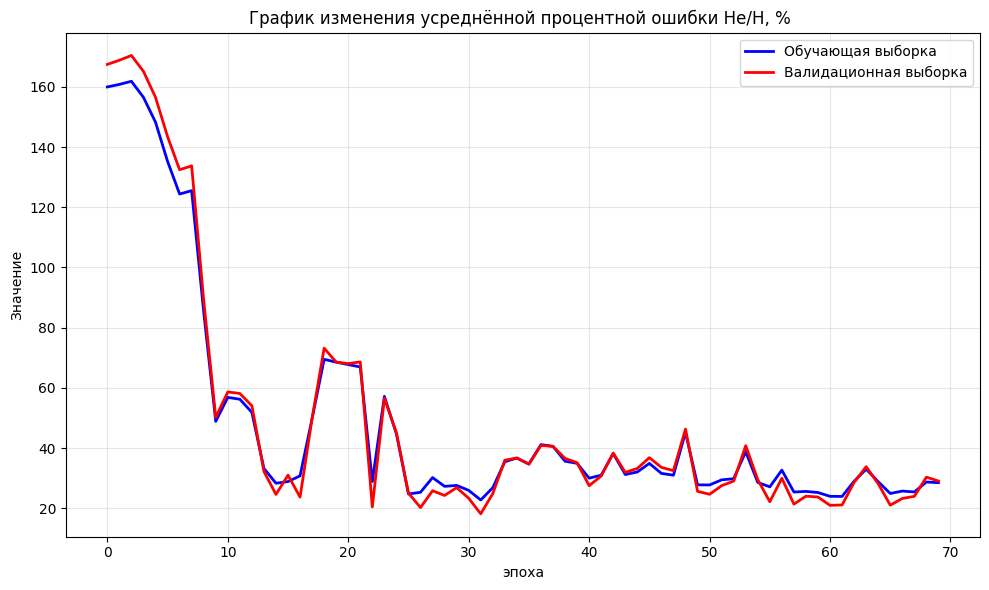

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

sns.lineplot(x=range(len(train_losses)), y=mape_train, label='Обучающая выборка', color='blue', linewidth=2)
sns.lineplot(x=range(len(val_losses)), y=mape_val, label='Валидационная выборка', color='red', linewidth=2)

plt.title('График изменения усреднённой процентной ошибки He/H, % ')
plt.xlabel('эпоха')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy  as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
def read_txt_to_dataframe_v2(file_path, column_names=None):
    """
    Альтернативная версия с использованием read_csv и регулярного выражения
    """
    
    if column_names is None:
        column_names = ['VV', 'FullAbs', 'CI']
    elif len(column_names) != 3:
        raise ValueError("Должно быть ровно 3 имени столбцов")
    
    try:
        # Используем регулярное выражение для разделителя: 
        # пробел или табуляция, один или более раз
        df = pd.read_csv(
            file_path,
            sep=r'[ \t]+',  # регулярное выражение для пробелов и табуляций
            header=None,
            names=column_names,
            engine='python',  # python engine поддерживает regex разделители
            encoding='utf-8',
            skip_blank_lines=True
        )
        
        # Очистка строковых значений
        if df['CI'].isna().all(): df['CI'] = df['CI'].fillna(0)
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].str.strip()
        
        # print(f"Файл успешно прочитан")
        # print(f"Размер DataFrame: {df.shape}")
        
        return df
        
    except Exception as e:
        raise Exception(f"Ошибка при чтении файла: {e}")
    
def get_real_observations(path_to_folder:str | Path):
    path_to_folder = Path(path_to_folder)
    answer = {}
    for file in list(path_to_folder.rglob("*.txt")): 
        df_Wasp52 = read_txt_to_dataframe_v2(str(file))
        print(file)
        # Удаляем строки с NaN (если были ошибки преобразования)
        df_Wasp52_clean = df_Wasp52.dropna()

        df_Wasp52_clean["VV"] = (
            df_Wasp52_clean["VV"]
            .astype(str)                      # гарантируем строковый тип
            .str.replace(',', '.')            # заменяем запятые на точки
            .str.replace(' ', '')             # удаляем пробелы если есть
        )
        df_Wasp52_clean["FullAbs"] = (
            df_Wasp52_clean["FullAbs"]
            .astype(str)                      # гарантируем строковый тип
            .str.replace(',', '.')            # заменяем запятые на точки
            .str.replace(' ', '')             # удаляем пробелы если есть
        )
        # Теперь можно преобразовывать в numpy float32
        VV = df_Wasp52_clean["VV"].to_numpy(np.float32)
        X = df_Wasp52_clean["FullAbs"].to_numpy(np.float32)
        pname = Path(file).stem
        if pname!="Wasp-121b":
            X /= 100
        VV /= 10.07
        
        # Исходные данные (возрастающие x)
        x_orig = VV
        y_orig = X   # последний отрезок резко вверх

        # Запросы: внутри и вне диапазона
        x_query = np.linspace(-5,5,101)
        
        # --- Вариант 1: линейная интерполяция с экстраполяцией по последнему отрезку ---
        f_linear_ext = interp1d(x_orig, y_orig,
                                kind='linear',
                                fill_value='extrapolate')   # ключевой параметр
    
        # print(df_Wasp52)
        y_linear_ext = f_linear_ext(x_query)

        

        # --- Вариант 2: более безопасная экстраполяция (постоянные значения на краях) ---
        f_const_ext = interp1d(x_orig, y_orig,
                            kind='linear',
                            fill_value=(y_orig[0], y_orig[-1]),   # задать явно
                            bounds_error=False)

        y_const_ext = f_const_ext(x_query)
       

        answer[pname] = {
            "V_orig":VV,
            "FullAbs_orig":X,
            "V_interp":x_query,
            "FullAbs_interp":y_const_ext
        }
    return answer

answer = get_real_observations("real_observations")


real_observations/HD189733b_B.txt
real_observations/HD209458.txt
real_observations/HD189733b_A.txt
real_observations/Wasp-52b.txt
real_observations/Wasp-107b.txt
real_observations/Wasp-121b.txt
real_observations/Wasp-69b_A.txt
real_observations/Hat-P-32b.txt
real_observations/Wasp-69b_B.txt


/tmp/ipykernel_682430/3697913341.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Wasp52_clean["VV"] = (
/tmp/ipykernel_682430/3697913341.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Wasp52_clean["FullAbs"] = (


In [96]:
answer

{'HD189733b_B': {'V_orig': array([-17.299435  , -16.941837  , -16.405443  , -15.926812  ,
         -15.448183  , -14.911788  , -14.433159  , -13.954528  ,
         -13.8362465 , -13.478649  , -13.178818  , -12.760706  ,
         -12.403109  , -11.924479  , -11.566882  , -11.267051  ,
         -10.909454  , -10.430824  , -10.012712  ,  -9.655114  ,
          -9.058203  ,  -8.700605  ,  -8.221976  ,  -7.9221454 ,
          -7.5645485 ,  -7.1464353 ,  -6.846604  ,  -6.428491  ,
          -6.1314106 ,  -5.7738132 ,  -5.413466  ,  -4.8770704 ,
          -4.458957  ,  -4.040844  ,  -3.5622144 ,  -3.0863357 ,
          -2.7865045 ,  -2.3683915 ,  -2.1290765 ,  -1.8319961 ,
          -1.6531976 ,  -1.4716485 ,  -1.4138829 ,  -1.2323338 ,
          -1.0535353 ,  -0.8142204 ,  -0.51714003,  -0.21730883,
           0.0797716 ,   0.43736845,   0.67668325,   0.91599804,
           1.0947964 ,   1.2158293 ,   1.3946276 ,   1.6339425 ,
           1.8127408 ,   2.1703377 ,   2.349136  ,   2.8277657 ,


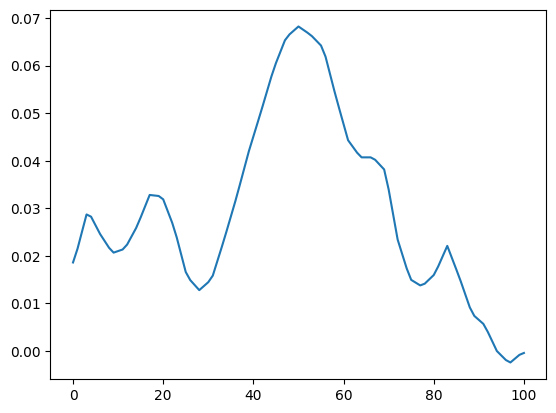

In [41]:
plt.plot(answer['Hat-P-32b']['FullAbs_interp'])

In [8]:
import torch
import numpy as np
from typing import Tuple, Union
import torch
import torch.nn as nn
import torch.nn.functional as F
def normalize_spectrum(S, method='area'):
    """
    S: (B, 101) или (101,)
    method: 'area' (интеграл=1) или 'max' (амплитуда=1)
    """
    if method == 'area':
        return S / (torch.sum(torch.abs(S), dim=-1, keepdim=True) + 1e-8)
    elif method == 'max':
        return S / (torch.max(torch.abs(S), dim=-1, keepdim=True).values + 1e-8)
    return S

def get_validation_calibrated_top5(scores, threshold=0.8, n=5):
    """
    Простой вариант: penalize за отклонение от медианы валидации.
    Предпочитает scores, похожие на те, что модель реально выдаёт на валидации.
    """
    val_median = threshold
    
    calibrated_scores = {}
    for score, params in scores.items():
        # Близость к медиане валидации — это хорошо
        # Отклонение вверх (переобучение) штрафуется сильнее, чем вниз
        if score > val_median:
            penalty = (score - val_median) * 2.0  # сильный штраф за переобучение
        else:
            penalty = (val_median - score) * 0.5  # слабый штраф за недообучение
        
        calibrated = score - penalty
        calibrated_scores[calibrated] = params
    
    sorted_calibrated = sorted(calibrated_scores.items(), key=lambda x: x[0], reverse=True)
    return sorted_calibrated[:n], calibrated_scores

def compute_pair_score(model, spectrum, param_a, param_b, device=None):
    """
    Вычисляет cosine similarity между эмбеддингами спектра и параметров.
    
    Args:
        model: SpectralParamTwoTower
        spectrum: torch.Tensor [seq_len] или [1, seq_len]
        param_a, param_b: float или torch.Tensor [1]
    
    Returns:
        score: float
    """
    if device is None:
        device = next(model.parameters()).device
    model.to(device)
    model.eval()
    
    if isinstance(spectrum, np.ndarray):
        spectrum = torch.from_numpy(spectrum).float()
    if isinstance(param_a, np.ndarray):
        param_a = torch.from_numpy(param_a).float()
    if isinstance(param_b, np.ndarray):
        param_b = torch.from_numpy(param_b).float()
    # Подготовка спектра
    if spectrum.ndim == 1:
        spectrum = spectrum.unsqueeze(0)  # [1, seq_len]
    spectrum = normalize_spectrum(spectrum).to(device)
    # Подготовка параметров
    if isinstance(param_a, (float, int)):
        param_a = torch.tensor([param_a], device=device)
    if isinstance(param_b, (float, int)):
        param_b = torch.tensor([param_b], device=device)
    
    # Инференс + cosine similarity
    with torch.no_grad():
        z_spec, z_param, _,_ = model(spectrum, param_a, param_b)
        # z_spec = F.normalize(z_spec, p=2, dim=-1)
        # z_param = F.normalize(z_param, p=2, dim=-1)
        score = F.cosine_similarity(z_spec, z_param).item()
    
    return score

def run_chronos_multimodal_inference(
    model: torch.nn.Module,
    scaler,
    spectra: Union[np.ndarray, torch.Tensor],
    device: str = None,
    return_conf: bool = True
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Инференс MultiHeadChronosRegressor.
    Возвращает предсказания и оценки уверенности для ВСЕХ голов.
    
    Args:
        model: модель в режиме eval()
        scaler: обученный StandardScaler для денормализации предсказаний
        spectra: np.array или torch.Tensor формы [batch, seq_len] или [seq_len]
        device: 'cuda'/'cpu'. Если None, берётся из весов модели
        return_conf: если False, возвращает только preds
        
    Returns:
        preds: torch.Tensor [batch, num_heads, output_dim] (денормализованные)
        confs: torch.Tensor [batch, num_heads] (если return_conf=True)
    """
    if device is None:
        device = next(model.parameters()).device
        if device == torch.device('cpu') and torch.cuda.is_available():
            device = 'cuda'
    
    # Переносим модель на нужное устройство
    model = model.to(device)
    
    # ВАЖНО: Сохраняем ссылку на токенизатор и его boundaries
    tokenizer = None
    original_boundaries = None
    if hasattr(model, 'tokenizer'):
        tokenizer = model.tokenizer
        if hasattr(tokenizer, 'boundaries'):
            original_boundaries = tokenizer.boundaries
            # Убеждаемся, что boundaries на CPU
            tokenizer.boundaries = original_boundaries.cpu()
    
    # 1. Нормализация входа
    if isinstance(spectra, np.ndarray):
        spectra = torch.from_numpy(spectra).float()
    if spectra.ndim == 1:
        spectra = spectra.unsqueeze(0)  # [1, seq_len]
        
    # 2. Перенос на устройство модели
    spectra = spectra.to(device)
    
    # 3. Инференс
    model.eval()
    with torch.no_grad():
        preds = model(spectra)
    
    # Восстанавливаем boundaries после инференса (на всякий случай)
    if original_boundaries is not None:
        tokenizer.boundaries = original_boundaries
        
    # 4. Возврат на CPU и денормализация
    preds = preds.cpu()
    
    
    # Денормализация preds
    batch_size, num_heads, output_dim = preds.shape
    preds_flat = preds.reshape(-1, output_dim).numpy()  # [batch * num_heads, output_dim]
    preds_flat_denorm = scaler.inverse_transform(preds_flat)
    preds_denorm = torch.from_numpy(preds_flat_denorm).reshape(batch_size, num_heads, output_dim).float()
    
    return preds, preds_denorm

In [9]:
from utils import load_model_with_architecture
import pickle

# загружаем скалеры для инференса
with open('inference_ready_weights/scaler_xuv.pkl', 'rb') as f:
    scaler_xuv = pickle.load(f)
with open('inference_ready_weights/scaler_he.pkl', 'rb') as f:
    scaler_he = pickle.load(f)
with open('inference_ready_weights/scaler_msw.pkl', 'rb') as f:
    scaler_msw = pickle.load(f)
# загружаем модели для параметрического определения
model_xuv = load_model_with_architecture("inference_ready_weights/best_xuv_transformer.pkl")
model_he = load_model_with_architecture("inference_ready_weights/best_helium_conv.pkl")
model_msw = load_model_with_architecture("inference_ready_weights/best_msw_transformer.pkl")
# TODO сохранить xgboost для H2a и потренить бинарный классификатор
model_h2a = load_model_with_architecture("inference_ready_weights/best_h2a_conv.pkl")
# скоринговая модель
# хорошо работает на посчитаных планетах
model_scoring = load_model_with_architecture("best_voigt_reconstructor_21.pkl", 'cpu')
# model_scoring = load_model_with_architecture("best_voigt_reconstructor_33.pkl")

# model_scoring = load_model_with_architecture("best_voigt_reconstructor_bal1.pkl")



✅ Модель со всей архитектурой загружена из inference_ready_weights/best_xuv_transformer.pkl
✅ Модель со всей архитектурой загружена из inference_ready_weights/best_helium_conv.pkl
✅ Модель со всей архитектурой загружена из inference_ready_weights/best_msw_transformer.pkl
✅ Модель со всей архитектурой загружена из inference_ready_weights/best_h2a_conv.pkl
✅ Модель со всей архитектурой загружена из best_voigt_reconstructor_21.pkl


In [10]:
def get_validation_calibrated_top5(scores, threshold=0.8, n=5):
    """
    Простой вариант: penalize за отклонение от медианы валидации.
    Предпочитает scores, похожие на те, что модель реально выдаёт на валидации.
    """
    val_median = threshold
    
    calibrated_scores = {}
    for score, params in scores.items():
        # Близость к медиане валидации — это хорошо
        # Отклонение вверх (переобучение) штрафуется сильнее, чем вниз
        if score > val_median:
            penalty = (score - val_median) * 2  # сильный штраф за переобучение
        else:
            penalty = (val_median - score) * 0.5  # слабый штраф за недообучение
        
        calibrated = score - penalty
        calibrated_scores[calibrated] = params
    
    sorted_calibrated = sorted(calibrated_scores.items(), key=lambda x: x[0], reverse=True)
    return sorted_calibrated[:n], calibrated_scores

In [91]:
def get_xuv_and_he_prediction(spectra, model_xuv, scaler_xuv, model_he, scaler_he, model_scoring):
    y_const_ext = spectra
    xuv_candidates, xuv_candidates_denormalized = run_chronos_multimodal_inference(model=model_xuv,
                                    scaler=scaler_xuv,
                                    spectra=y_const_ext,
                                    device='cpu')

    he_candidates, he_candidates_denormalized = run_chronos_multimodal_inference(model=model_he,
                                    scaler=scaler_he,
                                    spectra=y_const_ext,
                                    device='cpu')

    grid_i, grid_j = torch.meshgrid(torch.arange(len(he_candidates.squeeze(0))), torch.arange(len(xuv_candidates.squeeze(0))), indexing='ij')

    # Индексируем тензоры по сетке

    combinations = torch.stack([he_candidates.squeeze(0)[grid_i.flatten()], xuv_candidates.squeeze(0)[grid_j.flatten()]], dim=1)
    # combinations.shape
    scores = {}
    for pair in combinations:
        score = compute_pair_score(model_scoring, y_const_ext, pair[0], pair[1], device='cpu')
        ans = []
        for pred, scaler in zip((pair[0], pair[1]), (scaler_he, scaler_xuv)):
            
            preds_flat = pred.reshape(-1, 1).numpy()  # [batch * num_heads, output_dim]
            preds_flat_denorm = scaler.inverse_transform(preds_flat)
            # preds_denorm = torch.from_numpy(preds_flat_denorm).float()
            ans.append(preds_flat_denorm[0][0])
        scores[score] = ans
        # print(ans, score)

    sorted_items, calibrated_scores = get_validation_calibrated_top5(scores,0.66, n=5)
    # sorted_items = sorted(scores.items(), key=lambda x: x[0], reverse=True)
    top5 = sorted_items[:7]
    

    # for score, params in top5:
    #     print(f"Score: {score:.4f}, Params: He/H={params[0]:.6f}, XUVInt={params[1]:.6f}")
    return top5, scores
@torch.no_grad
def get_msw_prediction(spectra, model_msw, scaler_msw, device="cpu"):
    if device is None:
        device = next(model.parameters()).device
        if device == torch.device('cpu') and torch.cuda.is_available():
            device = 'cuda'
    
    # Переносим модель на нужное устройство
    model_msw = model_msw.to(device)
    model_msw.eval()
    # ВАЖНО: Сохраняем ссылку на токенизатор и его boundaries
    tokenizer = None
    original_boundaries = None
    if hasattr(model_msw, 'tokenizer'):
        tokenizer = model_msw.tokenizer
        if hasattr(tokenizer, 'boundaries'):
            original_boundaries = tokenizer.boundaries
            # Убеждаемся, что boundaries на CPU
            tokenizer.boundaries = original_boundaries.cpu()
    
    # 1. Нормализация входа
    if isinstance(spectra, np.ndarray):
        spectra = torch.from_numpy(spectra).float()
    if spectra.ndim == 1:
        spectra = spectra.unsqueeze(0)  # [1, seq_len]
        
    # 2. Перенос на устройство модели
    spectra = spectra.to(device)
    msw_raw = model_msw(spectra)
    msw_raw.reshape(-1, 1).numpy()
    msw_log = scaler_msw.inverse_transform(msw_raw)
    msw = np.expm1(msw_log)
    return msw

sdasd = {}
for pname, p_info in answer.items():
    top5, scores = get_xuv_and_he_prediction(p_info['FullAbs_interp'], model_xuv, scaler_xuv, model_he, scaler_he, model_scoring)
    msw = get_msw_prediction(p_info["FullAbs_interp"], model_msw, scaler_msw)
    model_h2a.to('cpu')
    h2a = model_h2a.predict(torch.from_numpy(p_info["FullAbs_interp"]).float().unsqueeze(0), threshold=0.5)
    print(f"========================== Planet - {pname} ============================")
    print(" ")
    print(f" Msw = {msw}, H2a = {h2a}")
    for score, params in top5:
        print(f"Score: {score:.4f}, Params: He/H={params[0]:.4f}, XUVInt={int(params[1])}")
    # print(scores)
    sdasd[pname] = scores
    print(" ")
    print(" ")
    

========================== Planet - HD189733b_B ============================
 
 Msw = [[6.59431831e+13]], H2a = tensor([1], dtype=torch.int32)
Score: 0.6135, Params: He/H=0.0247, XUVInt=12
Score: 0.6104, Params: He/H=0.0143, XUVInt=12
Score: 0.6039, Params: He/H=0.0652, XUVInt=12
Score: 0.5839, Params: He/H=0.0143, XUVInt=24
Score: 0.5746, Params: He/H=0.0247, XUVInt=24
 
 
========================== Planet - HD209458 ============================
 
 Msw = [[2.99862922e+12]], H2a = tensor([0], dtype=torch.int32)
Score: 0.5683, Params: He/H=0.0656, XUVInt=1
Score: 0.5117, Params: He/H=0.0656, XUVInt=42
Score: 0.4735, Params: He/H=0.0241, XUVInt=1
Score: 0.4675, Params: He/H=0.0656, XUVInt=10
Score: 0.4603, Params: He/H=0.0143, XUVInt=1
 
 
========================== Planet - HD189733b_A ============================
 
 Msw = [[6.01985721e+13]], H2a = tensor([1], dtype=torch.int32)
Score: 0.5047, Params: He/H=0.2452, XUVInt=47
Score: 0.4930, Params: He/H=0.2452, XUVInt=43
Score: 0.4453, Pa

========================== Planet - HD189733b_B ============================
 
 Msw = [[6.59431831e+13]], H2a = tensor([1], dtype=torch.int32)
Score: 0.6135, Params: He/H=0.0247, XUVInt=12
Score: 0.6104, Params: He/H=0.0143, XUVInt=12
Score: 0.6039, Params: He/H=0.0652, XUVInt=12
Score: 0.5839, Params: He/H=0.0143, XUVInt=24
Score: 0.5746, Params: He/H=0.0247, XUVInt=24

 
========================== Planet - Wasp-107b ============================
 
 Msw = [[3.5068243e+13]], H2a = tensor([1], dtype=torch.int32)
Score: 0.6568, Params: He/H=0.1585, XUVInt=60
Score: 0.6285, Params: He/H=0.1585, XUVInt=41
Score: 0.5704, Params: He/H=0.2530, XUVInt=41
Score: 0.5477, Params: He/H=0.2530, XUVInt=60
Score: 0.4677, Params: He/H=0.1585, XUVInt=26
 
 
========================== Planet - Wasp-69b_A ============================
 
 Msw = [[1.34152109e+12]], H2a = tensor([1], dtype=torch.int32)
Score: 0.5508, Params: He/H=0.0642, XUVInt=4
Score: 0.4894, Params: He/H=0.0254, XUVInt=4
Score: 0.4812, Params: He/H=0.0154, XUVInt=4
Score: 0.4751, Params: He/H=0.0642, XUVInt=42
Score: 0.4372, Params: He/H=0.0642, XUVInt=14
 
 
========================== Planet - Hat-P-32b ============================
 
 Msw = [[4.20742359e+13]], H2a = tensor([0], dtype=torch.int32)
Score: 0.4307, Params: He/H=0.2540, XUVInt=13
Score: 0.4292, Params: He/H=0.2540, XUVInt=44
Score: 0.4223, Params: He/H=0.2540, XUVInt=40
Score: 0.4126, Params: He/H=0.2540, XUVInt=34
Score: 0.3976, Params: He/H=0.2540, XUVInt=23
 
 
<!-- ========================== Planet - Wasp-69b_B ============================
 
 Msw = [[6.77980527e+13]], H2a = tensor([1], dtype=torch.int32)
Score: 0.5864, Params: He/H=0.2460, XUVInt=57
Score: 0.5833, Params: He/H=0.2460, XUVInt=10
Score: 0.5520, Params: He/H=0.2460, XUVInt=24
Score: 0.5388, Params: He/H=0.2460, XUVInt=37
Score: 0.5363, Params: He/H=0.2460, XUVInt=31 -->

In [94]:
test_dataset = pd.DataFrame(process_files_in_folder_with_params("dataset_check"))
# test_dataset[['XUVInt', 'Msw', 'Helium']] = test_dataset[['XUVInt', 'Msw', 'Helium']].values.astype(np.float32)
test_dataset

Ошибка при загрузке данных из dataset_check/dataset_new_hd: [Errno 21] Is a directory: 'dataset_check/dataset_new_hd'


,V,FullAbs,PName,Msw,XUVInt,H2a,Helium
0,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.000390077, 0.000410544, 0.000440816, 0.0004...",HD189733b,6e13,24,1,0.024022
1,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.000320758, 0.0003242, 0.000331838, 0.000345...",HD189733b,6e13,12,1,0.014022
2,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.000477891, 0.000487644, 0.000504219, 0.0005...",HD189733b,6e13,12,1,0.024022
3,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.000317077, 0.000337479, 0.00036544, 0.00040...",HD189733b,6e13,24,0,0.024022
4,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.000243893, 0.000252544, 0.000267124, 0.0002...",HD189733b,6e13,12,0,0.024022
5,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.000159559, 0.000164195, 0.000172188, 0.0001...",HD189733b,6e13,12,0,0.014022
6,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.000977289, 0.00121519, 0.00151374, 0.001885...",HATP32b,42e12,44,1,0.25022
7,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.0020351, 0.00238788, 0.00281242, 0.00332028...",HATP32b,42e12,44,0,0.25022
8,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.000802313, 0.000906445, 0.00103489, 0.00119...",HATP32b,42e12,13,0,0.25022
9,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00081512, 0.00101111, 0.00125789, 0.0015656...",HATP32b,42e12,34,1,0.252022


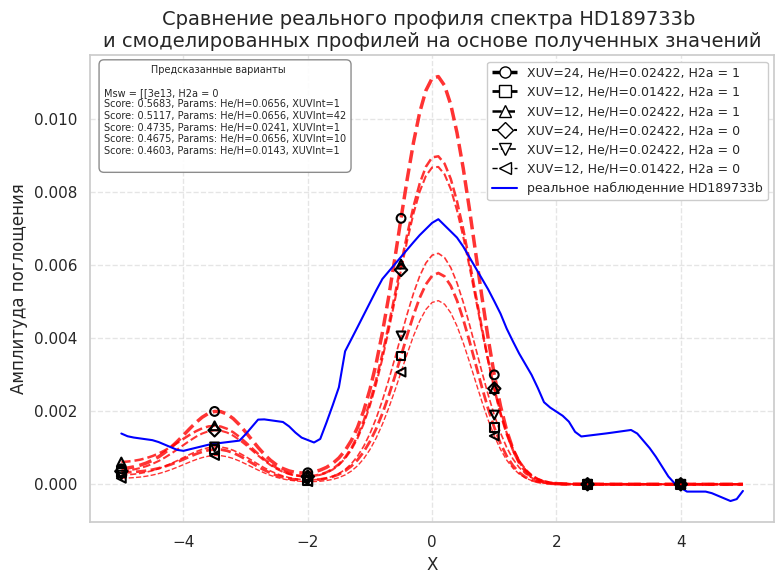

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
# need_dataset = df[(df['PName']=="HD189733b_B") & (df['Helium']>0.14) & (df['Helium']<0.26) & (df['XUVInt']>=25) & (df['XUVInt']<60)]
# ============================================================
# 1. ВАШИ ДАННЫЕ (замените на реальные)
# ============================================================
# Предполагается, что df уже загружен и содержит нужные колонки
need_dataset = test_dataset[(test_dataset['PName'] == "HD189733b")]
x_data = []
y_data = []

for j in list(need_dataset.index):
    # x = np.linspace(-5, 5, 101)  # общий X (замените на ваши реальные x, если они разные)
    y = need_dataset["FullAbs"][j]    # ваши данные
    x = np.linspace(-5,5,len(y))
    x_data.append(x)
    y_data.append(y)

param_names = [
    f"XUV={need_dataset['XUVInt'][i]}, He/H={need_dataset['Helium'][i]}, H2a = {need_dataset['H2a'][i]}"
    for i in list(need_dataset.index)
]

# # ============================================================
# # 2. НАСТРОЙКИ
# # ============================================================
markers = ['o', 's', '^', 'D', 'v', '<', '>']
linewidths = [2.5, 2.0, 1.8, 1.5, 1.2, 1.0, 0.8]
colors = sns.color_palette("husl", 10)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# # ============================================================
# # 3. РИСУЕМ ГРАФИКИ
# # ============================================================
legend_elements = []  # для сбора объектов легенды


for i in range(len(need_dataset)):
    x = x_data[i]
    y = y_data[i]
    marker = markers[i%len(markers)]
    lw = linewidths[i%len(linewidths)]
    color = colors[i]
    # Основная линия
    try:
        plt.plot(x, y, color='red', linewidth=lw, alpha=0.8, linestyle='--')
    except Exception as e:
        continue
    # Маркеры с шагом
    step = 15
    indices = np.arange(0, len(x), step)
    plt.scatter(x[indices], y[indices], marker=marker, s=40,
                facecolors='none', edgecolors='black', linewidths=1.5, zorder=5)
    
    # Добавляем элемент в легенду (линия + маркер)
    legend_elements.append(
        Line2D([0], [0], marker=marker, color='black', linewidth=lw,
               linestyle='--', markersize=8, markerfacecolor='white',
               label=param_names[i])
    )

plt.plot(answer['HD189733b_B']['V_interp'],answer['HD189733b_B']['FullAbs_interp'], color="blue")
legend_elements.append(
        Line2D([0], [0], color='blue',
               linestyle='-', markersize=8,
               label="реальное наблюденние HD189733b")
    )

predictions_text =( """               Предсказанные варианты\n
Msw = 6e13, H2a = 1
Score: 0.6135, Params: He/H=0.0247, XUVInt=12
Score: 0.6104, Params: He/H=0.0143, XUVInt=12
Score: 0.6039, Params: He/H=0.0652, XUVInt=12
Score: 0.5839, Params: He/H=0.0143, XUVInt=24
Score: 0.5746, Params: He/H=0.0247, XUVInt=24
                    """)

plt.text(
    0.02, 0.98,                    # позиция (относительные координаты: 0-1)
    predictions_text,              # текст
    transform=plt.gca().transAxes, # относительные координаты осей
    fontsize=7,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        edgecolor='gray',
        alpha=0.9
    )
)
# ============================================================
# 4. ЛЕГЕНДА И ОФОРМЛЕНИЕ
# ============================================================
plt.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=1)

plt.xlabel("X", fontsize=12)
plt.ylabel("Амплитуда поглощения", fontsize=12)
plt.title("Сравнение реального профиля спектра HD189733b \nи смоделированных профилей на основе полученных значений", fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Лучший профиль: индекс 0
Интегральная разница: 10.81%


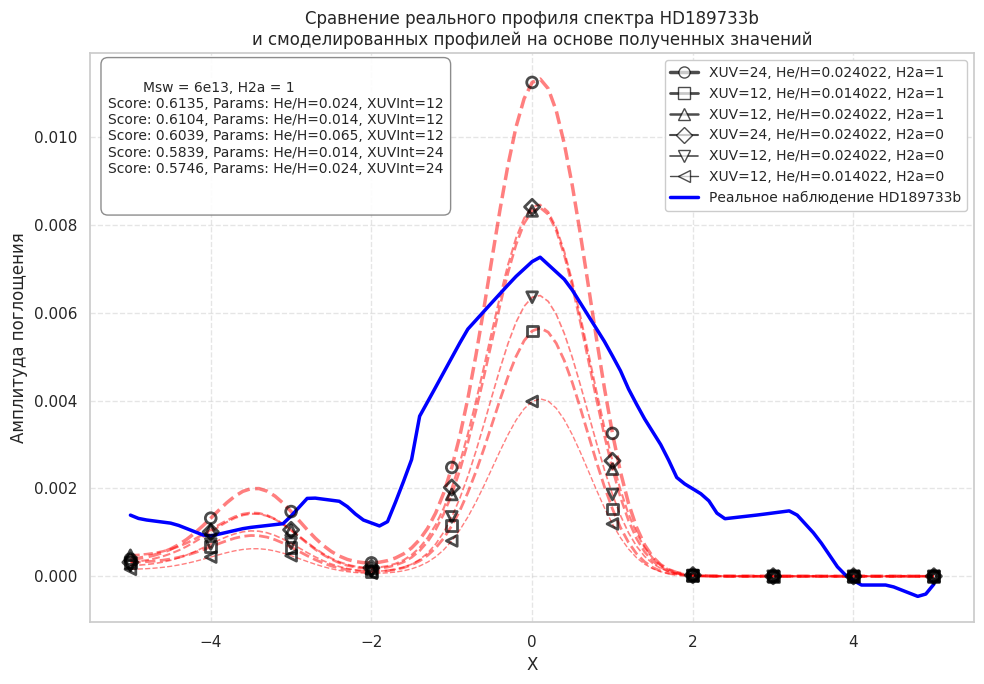


СРАВНЕНИЕ ИНТЕГРАЛЬНЫХ РАЗНИЦ
№   Параметры                                     Δ интеграла (%)
----------------------------------------------------------------------
*0  XUV=24, He/H=0.024022, H2a=1                  10.81          
 1  XUV=12, He/H=0.014022, H2a=1                  44.49          
 2  XUV=12, He/H=0.024022, H2a=1                  51.16          
 3  XUV=24, He/H=0.024022, H2a=0                  50.20          
 4  XUV=12, He/H=0.024022, H2a=0                  54.66          
 5  XUV=12, He/H=0.014022, H2a=0                  22.29          


In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
import matplotlib.patches as mpatches

# ============================================================
# 1. ВАШИ ДАННЫЕ
# ============================================================
need_dataset = test_dataset[(test_dataset['PName'] == "HD189733b")]

x_data = []
y_data = []

for j in list(need_dataset.index):
    y = need_dataset["FullAbs"][j]
    x = np.linspace(-5, 5, len(y))
    x_data.append(x)
    y_data.append(y)

param_names = [
    f"XUV={need_dataset['XUVInt'][i]}, He/H={need_dataset['Helium'][i]}, H2a={need_dataset['H2a'][i]}"
    for i in list(need_dataset.index)
]

# Реальное наблюдение
real_x = answer['HD189733b_B']['V_interp']
real_y = answer['HD189733b_B']['FullAbs_interp']

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ РАСЧЁТА ИНТЕГРАЛЬНОЙ РАЗНИЦЫ
# ============================================================
def peak_similarity_score(x_real, y_real, x_synth, y_synth):
    """
    Оценивает схожесть двух профилей по амплитуде пика и ширине на полувысоте.
    
    Returns:
        score: общий счёт (0 = идеально, 1 = большая разница)
        amp_score: относительная разница амплитуд (0-1)
        fwhm_score: относительная разница ширин (0-1)
    """
    def get_peak_params(x, y):
        # Амплитуда
        amp = np.max(y)
        x_peak = x[np.argmax(y)]
        
        # FWHM
        half = amp / 2
        # Левый край
        left = np.where(y[:np.argmax(y)] <= half)[0]
        x_left = np.interp(half, y[left[-1:left[-1]+2]], x[left[-1:left[-1]+2]]) if len(left) > 0 else x[0]
        # Правый край
        right = np.where(y[np.argmax(y):] <= half)[0]
        x_right = np.interp(half, y[right[0]:right[0]+2], x[right[0]:right[0]+2]) if len(right) > 0 else x[-1]
        
        fwhm = x_right - x_left
        return amp, fwhm
    
    amp_r, fwhm_r = get_peak_params(x_real, y_real)
    amp_s, fwhm_s = get_peak_params(x_synth, y_synth)
    
    # Относительные разницы
    amp_diff = abs(amp_r - amp_s) / (amp_r + 1e-7)
    fwhm_diff = abs(fwhm_r - fwhm_s) / (fwhm_r + 1e-7)
    
    # Общий счёт (среднее)
    score = (amp_diff) + (fwhm_diff)
    
    return abs(score), amp_diff, fwhm_diff

# ============================================================
# 3. РАСЧЁТ ИНТЕГРАЛЬНЫХ РАЗНИЦ ДЛЯ ВСЕХ ПРОФИЛЕЙ
# ============================================================
integral_diffs = []
best_idx = -1
best_diff = float('inf')

for i in range(len(need_dataset)):
    diff, _, _ = peak_similarity_score(real_x, real_y, x_data[i], y_data[i])
    integral_diffs.append(diff)
    if diff < best_diff:
        best_diff = diff
        best_idx = i

print(f"\nЛучший профиль: индекс {best_idx}")
print(f"Интегральная разница: {best_diff*100:.2f}%")

# ============================================================
# 4. ПОСТРОЕНИЕ ГРАФИКА
# ============================================================
markers = ['o', 's', '^', 'D', 'v', '<', '>']
linewidths = [2.5, 2.0, 1.8, 1.5, 1.2, 1.0, 0.8]
colors = sns.color_palette("husl", 10)
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 7))

legend_elements = []

# 1. Рисуем все синтезированные профили
for i in range(len(need_dataset)):
    x = x_data[i]
    y = y_data[i]
    marker = markers[i % len(markers)]
    lw = linewidths[i % len(linewidths)]
    color = colors[i]
    
    step = 10
    indices = np.arange(0, len(x), step)
    
    ax.plot(x, y, color='red', linewidth=lw, alpha=0.5, linestyle='--')
    ax.scatter(x[indices], y[indices], marker=marker, s=60,
               facecolors='none', edgecolors='black', linewidths=2, zorder=5, alpha=0.7)
    
    # Добавляем в легенду только если это лучший профиль
    # if i == best_idx:
    #     line_label = f"{param_names[i]} (лучший, ΔI={integral_diffs[i]*100:.1f}%)"
    # else:
    line_label = param_names[i]
    
    legend_elements.append(
        Line2D([0], [0], marker=marker, color='black', linewidth=lw,
               linestyle='-', markersize=8, markerfacecolor='white',
               label=line_label, alpha=0.7)
    )

# 2. Реальное наблюдение
ax.plot(real_x, real_y, color='blue', linewidth=2.5, linestyle='-', 
        label="Реальное наблюдение HD189733b")

legend_elements.append(
    Line2D([0], [0], color='blue', linewidth=2.5, linestyle='-',
           label="Реальное наблюдение HD189733b")
)

# 3. ЗАКРАШИВАНИЕ ОБЛАСТИ МЕЖДУ РЕАЛЬНЫМ И ЛУЧШИМ ПРОФИЛЕМ
# if best_idx >= 0:
#     x_best = x_data[best_idx]
#     y_best = y_data[best_idx]
    
#     # Интерполяция на общую сетку
#     x_common = np.linspace(max(real_x.min(), x_best.min()), 
#                            min(real_x.max(), x_best.max()), 500)
#     y_real_interp = np.interp(x_common, real_x, real_y)
#     y_best_interp = np.interp(x_common, x_best, y_best)
    
#     # Закрашивание области между кривыми
#     ax.fill_between(x_common, y_real_interp, y_best_interp, color='grey',
#                 alpha=.3, hatch='///', edgecolor='black', linewidth=1,
#                 label=f'Область расхождения (ΔI = {best_diff*100:.1f}%)')
    
#     # Текст с информацией о лучшем профиле
#     # ax.text(0.02, 0.8, 
#     #         f"Лучший профиль:\n{param_names[best_idx]}\nАмплитудно-широтная разница: {best_diff*100:.2f}%",
#     #         fontsize=8, verticalalignment='top',
#     #         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))
    
#     hatch_patch = mpatches.Patch(edgecolor='black', hatch='///', facecolor='grey',alpha=.4,linewidth=1,
#                                 label=f'Область расхождения (ΔI = {best_diff*100:.1f}%)')
#     legend_elements.append(hatch_patch)
# 4. Текст с предсказаниями
predictions_text = f"""
        Msw = 6e13, H2a = 1
Score: 0.6135, Params: He/H=0.024, XUVInt=12
Score: 0.6104, Params: He/H=0.014, XUVInt=12
Score: 0.6039, Params: He/H=0.065, XUVInt=12
Score: 0.5839, Params: He/H=0.014, XUVInt=24
Score: 0.5746, Params: He/H=0.024, XUVInt=24
 
"""

ax.text(0.02, 0.98, predictions_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

# ============================================================
# 5. ОФОРМЛЕНИЕ
# ============================================================
ax.set_xlabel("X", fontsize=12)
ax.set_ylabel("Амплитуда поглощения", fontsize=12)
ax.set_title("Сравнение реального профиля спектра HD189733b\nи смоделированных профилей на основе полученных значений", fontsize=12)
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=1, ncol=1)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('hd.svg', format='svg', dpi=500, bbox_inches='tight')
plt.show()

# ============================================================
# 6. ВЫВОД ТАБЛИЦЫ ИНТЕГРАЛЬНЫХ РАЗНИЦ
# ============================================================
print("\n" + "=" * 60)
print("СРАВНЕНИЕ ИНТЕГРАЛЬНЫХ РАЗНИЦ")
print("=" * 60)
print(f"{'№':<3} {'Параметры':<45} {'Δ интеграла (%)':<15}")
print("-" * 70)

for i, (params, diff) in enumerate(zip(param_names, integral_diffs)):
    marker = '*' if i == best_idx else ' '
    print(f"{marker}{i:<2} {params:<45} {diff*100:<15.2f}")

print("=" * 60)

In [22]:
x_common

array([-5.        , -4.97995992, -4.95991984, -4.93987976, -4.91983968,
       -4.8997996 , -4.87975952, -4.85971944, -4.83967936, -4.81963928,
       -4.7995992 , -4.77955912, -4.75951904, -4.73947896, -4.71943888,
       -4.6993988 , -4.67935872, -4.65931864, -4.63927856, -4.61923848,
       -4.5991984 , -4.57915832, -4.55911824, -4.53907816, -4.51903808,
       -4.498998  , -4.47895792, -4.45891784, -4.43887776, -4.41883768,
       -4.3987976 , -4.37875752, -4.35871743, -4.33867735, -4.31863727,
       -4.29859719, -4.27855711, -4.25851703, -4.23847695, -4.21843687,
       -4.19839679, -4.17835671, -4.15831663, -4.13827655, -4.11823647,
       -4.09819639, -4.07815631, -4.05811623, -4.03807615, -4.01803607,
       -3.99799599, -3.97795591, -3.95791583, -3.93787575, -3.91783567,
       -3.89779559, -3.87775551, -3.85771543, -3.83767535, -3.81763527,
       -3.79759519, -3.77755511, -3.75751503, -3.73747495, -3.71743487,
       -3.69739479, -3.67735471, -3.65731463, -3.63727455, -3.61

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import dill
from torch.utils.data import DataLoader, TensorDataset

# ==================== КОНФИГУРАЦИЯ ====================
CONTEXT_LEN = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 150
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ==================== МОДЕЛЬ ====================
class ChronosBinaryClassifier(nn.Module):
    """
    Бинарный классификатор на основе энкодера Chronos (T5).
    Выход: вероятность класса 1 (после сигмоиды).
    """
    def __init__(self, encoder, tokenizer, hidden_dims=[512, 256, 128], dropout=0.2):
        super().__init__()
        self.encoder = encoder
        self.tokenizer = tokenizer
        
        # Замораживаем энкодер
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        # Голова классификатора
        layers = []
        prev_dim = 512  # размерность эмбеддингов Chronos-T5-small
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.SiLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        
        # Выходной слой: один нейрон + сигмоида
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.head = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Args:
            x: тензор [batch, context_len] (временной ряд)
        Returns:
            proba: [batch, 1] — вероятность класса 1
        """
        # Токенизация (требует CPU)
        x_cpu = x.cpu()
        tokens = self.tokenizer.context_input_transform(x_cpu)
        token_ids = tokens[0] if isinstance(tokens, tuple) else tokens
        token_ids = token_ids.to(self.encoder.device)
        
        # Энкодинг
        enc_out = self.encoder(input_ids=token_ids).last_hidden_state
        
        # Берём последний токен как представление всей последовательности
        embedding = enc_out[:, -1, :]  # [batch, 512]
        
        # Классификационная голова
        proba = self.head(embedding)  # [batch, 1]
        
        return proba


# ==================== ФУНКЦИИ СОХРАНЕНИЯ/ЗАГРУЗКИ ====================
def save_model_with_architecture(model, filepath='best_h2a.pkl'):
    """Сохраняет модель полностью (архитектура + веса)"""
    with open(filepath, 'wb') as f:
        torch.save(model, f, pickle_module=dill)
    print(f"✅ Модель сохранена в {filepath}")


def load_model_with_architecture(filepath='best_h2a.pkl', device='cuda'):
    """Загружает модель полностью"""
    with open(filepath, 'rb') as f:
        model = torch.load(f, map_location=device, pickle_module=dill)
    model.eval()
    print(f"✅ Модель загружена из {filepath}")
    return model


# ==================== ТЕСТИРОВАНИЕ С МЕТРИКАМИ ====================
def evaluate_classification(model, loader, device='cuda', return_proba=False):
    """
    Оценивает бинарный классификатор на loader.
    
    Returns:
        dict: словарь с метриками (accuracy, precision, recall, f1, roc_auc)
        proba: массив вероятностей (если return_proba=True)
    """
    model.eval()
    all_targets = []
    all_probas = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            proba = model(x_batch)  # [batch, 1]
            
            all_probas.append(proba.cpu().numpy())
            all_targets.append(y_batch.numpy())
    
    # Объединяем
    y_true = np.concatenate(all_targets, axis=0).flatten()
    y_proba = np.concatenate(all_probas, axis=0).flatten()
    
    # Предсказания по порогу 0.5
    y_pred = (y_proba >= 0.5).astype(int)
    
    # Метрики
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }
    
    if return_proba:
        return metrics, y_proba, y_true
    return metrics


def full_evaluation_report(model, loader, device='cuda'):
    """Полный отчёт с метриками и матрицей ошибок"""
    metrics, y_proba, y_true = evaluate_classification(model, loader, device, return_proba=True)
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    print("\n" + "=" * 50)
    print("РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ H2a")
    print("=" * 50)
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1-score:  {metrics['f1']:.4f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
    print("\nМатрица ошибок (confusion matrix):")
    print(f"            Предсказано")
    print(f"           0      1")
    print(f"Истина 0  {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"      1  {cm[1,0]:5d}  {cm[1,1]:5d}")
    print("=" * 50)
    
    return metrics, y_proba, y_true


def plot_roc_curve(y_true, y_proba, save_path=None):
    """Строит ROC-кривую"""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC-кривая (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Случайный классификатор')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR, Recall)')
    plt.title('ROC-кривая для классификации H2a')
    plt.legend()
    plt.grid(alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"ROC-кривая сохранена в {save_path}")
    plt.show()


# ==================== ОЦЕНКА ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ (БУТСТРАП) ====================
def bootstrap_confidence_interval(loader, model, n_bootstrap=1000, ci_percentile=95, device='cuda'):
    """
    Оценивает доверительные интервалы для ROC-AUC и других метрик методом бутстрапа.
    
    Args:
        loader: DataLoader с тестовыми данными
        model: обученная модель
        n_bootstrap: количество бутстрап-итераций
        ci_percentile: доверительный уровень (95 → 95% CI)
        device: устройство
    
    Returns:
        dict: {
            'roc_auc': {'mean': float, 'std': float, 'ci_lower': float, 'ci_upper': float},
            'accuracy': {...},
            'precision': {...},
            'recall': {...},
            'f1': {...}
        }
    """
    # Получаем все предсказания и истинные метки
    model.eval()
    all_targets = []
    all_probas = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            proba = model(x_batch)
            all_probas.append(proba.cpu().numpy())
            all_targets.append(y_batch.numpy())
    
    y_true = np.concatenate(all_targets, axis=0).flatten()
    y_proba = np.concatenate(all_probas, axis=0).flatten()
    n_samples = len(y_true)
    
    # Функция вычисления метрик на бутстрап-выборке
    def compute_metrics_on_bootstrap(indices):
        y_true_boot = y_true[indices]
        y_proba_boot = y_proba[indices]
        y_pred_boot = (y_proba_boot >= 0.5).astype(int)
        
        return {
            'roc_auc': roc_auc_score(y_true_boot, y_proba_boot),
            'accuracy': accuracy_score(y_true_boot, y_pred_boot),
            'precision': precision_score(y_true_boot, y_pred_boot, zero_division=0),
            'recall': recall_score(y_true_boot, y_pred_boot, zero_division=0),
            'f1': f1_score(y_true_boot, y_pred_boot, zero_division=0)
        }
    
    # Бутстрап
    np.random.seed(42)
    bootstrap_metrics = {key: [] for key in compute_metrics_on_bootstrap(np.arange(n_samples)).keys()}
    
    for _ in range(n_bootstrap):
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        metrics_boot = compute_metrics_on_bootstrap(indices)
        for key in bootstrap_metrics:
            bootstrap_metrics[key].append(metrics_boot[key])
    
    # Вычисляем статистики
    results = {}
    for key, values in bootstrap_metrics.items():
        values = np.array(values)
        ci_lower = np.percentile(values, (100 - ci_percentile) / 2)
        ci_upper = np.percentile(values, (100 + ci_percentile) / 2)
        
        results[key] = {
            'mean': np.mean(values),
            'std': np.std(values, ddof=1),
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'all_samples': values  # для гистограммы
        }
    
    return results


def print_bootstrap_results(results):
    """Выводит результаты бутстрапа"""
    print("\n" + "=" * 60)
    print(f"ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (95% бутстрап, {len(results['roc_auc']['all_samples'])} итераций)")
    print("=" * 60)
    
    for metric in ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']:
        metric_name = metric.upper()
        if metric == 'roc_auc':
            metric_name = 'ROC-AUC'
            
        r = results[metric]
        print(f"\n{metric_name}:")
        print(f"  Среднее:   {r['mean']:.4f}")
        print(f"  Стд. откл.: {r['std']:.4f}")
        print(f"  95% CI:    [{r['ci_lower']:.4f}, {r['ci_upper']:.4f}]")
    
    print("=" * 60)


def plot_bootstrap_distribution(results, metric='roc_auc', save_path=None):
    """Строит гистограмму бутстрап-распределения для выбранной метрики"""
    data = results[metric]['all_samples']
    mean = results[metric]['mean']
    ci_lower = results[metric]['ci_lower']
    ci_upper = results[metric]['ci_upper']
    
    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    plt.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Среднее = {mean:.4f}')
    plt.axvline(ci_lower, color='green', linestyle='--', linewidth=2, label=f'95% CI нижн. = {ci_lower:.4f}')
    plt.axvline(ci_upper, color='green', linestyle='--', linewidth=2, label=f'95% CI верхн. = {ci_upper:.4f}')
    
    metric_name = 'ROC-AUC' if metric == 'roc_auc' else metric.upper()
    plt.xlabel(f'{metric_name}')
    plt.ylabel('Частота')
    plt.title(f'Бутстрап-распределение метрики {metric_name} (n={len(data)})')
    plt.legend()
    plt.grid(alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ==================== ЦИКЛ ОБУЧЕНИЯ ====================
def train_classifier(model, train_loader, val_loader, epochs=150, lr=0.001, device='cuda', patience=15):
    """
    Обучение бинарного классификатора с ранней остановкой по ROC-AUC.
    Сохраняется лучшая модель по ROC-AUC на валидации.
    """
    optimizer = torch.optim.Adam(model.head.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.BCELoss()  # Бинарная кросс-энтропия
    
    best_val_auc = 0.0
    best_epoch = 0
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    val_aucs = []
    
    for epoch in range(epochs):
        # ===== ОБУЧЕНИЕ =====
        model.train()
        train_loss = 0.0
        
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).float().view(-1, 1)
            
            optimizer.zero_grad()
            proba = model(x_batch)
            loss = criterion(proba, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # ===== ВАЛИДАЦИЯ =====
        val_metrics = evaluate_classification(model, val_loader, device)
        val_loss = None  # можно вычислить, если нужно
        val_auc = val_metrics['roc_auc']
        val_aucs.append(val_auc)
        
        print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val AUC: {val_auc:.4f}")
        
        # Сохраняем лучшую модель по ROC-AUC
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch + 1
            patience_counter = 0
            save_model_with_architecture(model, "best_h2a.pkl")
            print(f"  → Новая лучшая модель! AUC = {val_auc:.4f}")
        else:
            patience_counter += 1
        
        # Ранняя остановка
        if patience_counter >= patience:
            print(f"\nРанняя остановка на эпохе {epoch+1}. Лучший AUC = {best_val_auc:.4f} на эпохе {best_epoch}")
            break
    
    # Загружаем лучшую модель
    best_model = load_model_with_architecture("best_h2a.pkl", device)
    
    return best_model, train_losses, val_losses, val_aucs


# ==================== ПРИМЕР ИСПОЛЬЗОВАНИЯ ====================
if __name__ == "__main__":
    # ===== ЗАГРУЗКА ДАННЫХ =====
    # Предполагается, что у вас есть:
    # X_train, X_val, X_test — массивы формы [N, CONTEXT_LEN]
    # y_train, y_val, y_test — массивы формы [N] с метками 0/1
    
    # Преобразуем в тензоры и DataLoader
    # train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
    #                               torch.tensor(y_train, dtype=torch.float32))
    # val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
    #                             torch.tensor(y_val, dtype=torch.float32))
    # test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
    #                              torch.tensor(y_test, dtype=torch.float32))
    #
    # train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    # val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    # test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # ===== ИНИЦИАЛИЗАЦИЯ ЭНКОДЕРА CHRONOS =====
    from chronos import ChronosPipeline
    
    pipeline = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map=DEVICE,
        dtype=torch.float32,
    )
    encoder = pipeline.model.model.encoder
    tokenizer = pipeline.tokenizer
    
    # ===== СОЗДАНИЕ МОДЕЛИ =====
    model = ChronosBinaryClassifier(
        encoder=encoder,
        tokenizer=tokenizer,
        hidden_dims=[512, 256, 128],
        dropout=0.2
    ).to(DEVICE)
    
    # ===== ОБУЧЕНИЕ =====
    # best_model, train_losses, val_losses, val_aucs = train_classifier(
    #     model, train_loader, val_loader, epochs=150, lr=0.001, device=DEVICE, patience=15
    # )
    
    # ===== ТЕСТИРОВАНИЕ =====
    # full_evaluation_report(best_model, test_loader, DEVICE)
    #
    # # Доверительные интервалы
    # ci_results = bootstrap_confidence_interval(test_loader, best_model, n_bootstrap=1000, device=DEVICE)
    # print_bootstrap_results(ci_results)
    # plot_bootstrap_distribution(ci_results, metric='roc_auc')
    #
    # # ROC-кривая
    # _, y_proba, y_true = evaluate_classification(best_model, test_loader, DEVICE, return_proba=True)
    # plot_roc_curve(y_true, y_proba)